In [1]:
# CELL 1: install required packages
!pip install -q "dask[complete]" fastparquet pyarrow scikit-learn lightgbm xgboost matplotlib seaborn imbalanced-learn


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 31.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 59.3 MB/s eta 0:00:00


In [2]:
# CELL 2: LOAD & HARD-CODED PARAMS
import os
import pandas as pd
import numpy as np
from pathlib import Path
print("Running on Python", os.sys.version)

# ---------- HARDCODED ----------
DATA_PATH = "/yellow_tripdata.csv"   # <<-- your uploaded file path (hardcoded)
OUT_DIR = "/mnt/data/stream_results_hf"       # hf = high-f1
os.makedirs(OUT_DIR, exist_ok=True)

MAX_ROWS = 500_000   # number of raw rows to use
WINDOW_MINUTES = 3   # smaller window -> more samples (3 min)
N_LAT = 60           # grid resolution (tuneable)
N_LON = 60
ALPHA_EWMA = 0.2
LABEL_WINDOW_STD_MULT = 0.5  # label threshold = window_mean + multiplier * window_std
# geographic bounding box for NYC (safety filter)
LAT_MIN, LAT_MAX = 40.5, 41.0
LON_MIN, LON_MAX = -74.3, -73.7

# datetime col names expected in your sample
PICKUP_COLS = ['tpep_pickup_datetime', 'pickup_datetime', 'tpep_pickup']  # try these
DROPOFF_COLS = ['tpep_dropoff_datetime', 'dropoff_datetime', 'tpep_dropoff']

# ---------- LOAD ----------
print("Loading up to", MAX_ROWS, "rows from:", DATA_PATH)
# Use pandas.read_csv with nrows for reproducible behavior
df = pd.read_csv(DATA_PATH, nrows=MAX_ROWS, low_memory=False)
print("Initial shape:", df.shape)

# Try to detect pickup/dropoff columns and lat/lon
# normalize column names
df.columns = [c.strip() for c in df.columns]
cols = df.columns.tolist()

# detect pickup datetime
for c in PICKUP_COLS:
    if c in cols:
        PICKUP_DT = c
        break
else:
    raise RuntimeError("No pickup datetime column found. Columns: " + ", ".join(cols[:30]))

# detect dropoff if available
DROPOFF_DT = None
for c in DROPOFF_COLS:
    if c in cols:
        DROPOFF_DT = c
        break

# detect lat lon names
PULAT = None
PULON = None
for candidate in ['pickup_latitude', 'pickup_lat', 'pickup_latitude']:
    if candidate in cols:
        PULAT = candidate
        break
for candidate in ['pickup_longitude', 'pickup_lon', 'pickup_longitude']:
    if candidate in cols:
        PULON = candidate
        break
if PULAT is None or PULON is None:
    # try more guesses
    for c in cols:
        if 'lat' in c.lower() and 'pickup' in c.lower():
            PULAT = c
        if 'lon' in c.lower() and 'pickup' in c.lower():
            PULON = c
if PULAT is None or PULON is None:
    raise RuntimeError("Could not detect pickup lat/lon. Columns: " + ", ".join(cols[:40]))

print("Using pickup datetime:", PICKUP_DT, "dropoff datetime:", DROPOFF_DT, "lat:", PULAT, "lon:", PULON)

# Parse datetimes
df[PICKUP_DT] = pd.to_datetime(df[PICKUP_DT], errors='coerce', dayfirst=False)
if DROPOFF_DT:
    df[DROPOFF_DT] = pd.to_datetime(df[DROPOFF_DT], errors='coerce', dayfirst=False)

# compute trip_duration seconds if not present
if 'trip_duration' not in df.columns:
    if DROPOFF_DT:
        df['trip_duration'] = (df[DROPOFF_DT] - df[PICKUP_DT]).dt.total_seconds()
    else:
        # fallback: approximate from total_amount/fare? Just drop rows without duration
        df['trip_duration'] = np.nan

# drop invalid rows
df = df.dropna(subset=[PICKUP_DT, PULAT, PULON, 'trip_duration'])
df = df[(df[PULAT].between(LAT_MIN, LAT_MAX)) & (df[PULON].between(LON_MIN, LON_MAX))]
df = df[df['trip_duration'] > 0]
df = df.sort_values(PICKUP_DT).reset_index(drop=True)
print("After cleaning & filtering shape:", df.shape)

# Save a copy
df.head(3).to_csv(os.path.join(OUT_DIR, "sample_head.csv"), index=False)
print("Saved sample rows to", os.path.join(OUT_DIR, "sample_head.csv"))

# Basic display
print(df[[PICKUP_DT, PULAT, PULON, 'trip_duration']].head())


Running on Python 3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]
Loading up to 500000 rows from: /yellow_tripdata.csv
Initial shape: (500000, 19)
Using pickup datetime: tpep_pickup_datetime dropoff datetime: tpep_dropoff_datetime lat: pickup_latitude lon: pickup_longitude
After cleaning & filtering shape: (489858, 20)
Saved sample rows to /mnt/data/stream_results_hf/sample_head.csv
  tpep_pickup_datetime  pickup_latitude  pickup_longitude  trip_duration
0  2015-01-01 00:09:45        40.739292        -74.006416         1089.0
1  2015-01-01 00:09:45        40.727600        -73.992622          507.0
2  2015-01-01 00:09:45        40.717243        -74.009109          445.0
3  2015-01-01 00:09:45        40.736256        -73.996208         1191.0
4  2015-01-01 00:09:45        40.744549        -73.996727          245.0


In [3]:
# CELL 3: tile assignment and aggregation into 3-minute windows
import math
import pandas as pd
from datetime import timedelta

WINDOW_MIN = WINDOW_MINUTES  # from cell 2

def to_tile(lat, lon, lat_min=LAT_MIN, lat_max=LAT_MAX, lon_min=LON_MIN, lon_max=LON_MAX, nlat=N_LAT, nlon=N_LON):
    try:
        i = int(((lat - lat_min) / (lat_max - lat_min)) * nlat)
        j = int(((lon - lon_min) / (lon_max - lon_min)) * nlon)
        i = max(0, min(nlat-1, i))
        j = max(0, min(nlon-1, j))
        return f"{i}_{j}"
    except:
        return None

df['tile'] = df.apply(lambda r: to_tile(r[PULAT], r[PULON]), axis=1)
df['window_start'] = df[PICKUP_DT].dt.floor(f"{WINDOW_MIN}T")

# aggregation per window+tile
agg = df.groupby(['window_start','tile']).agg(
    mean_duration = ('trip_duration','mean'),
    std_duration = ('trip_duration','std'),
    count = ('trip_duration','count')
).reset_index()
agg['std_duration'] = agg['std_duration'].fillna(0.0)
print("Aggregated shape (tile-window):", agg.shape)

# quick stats
print(agg[['mean_duration','std_duration','count']].describe())
agg.head(5).to_csv(os.path.join(OUT_DIR,'agg_preview.csv'), index=False)
print("Saved agg_preview.csv")


/tmp/ipython-input-555503459.py:19: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  df['window_start'] = df[PICKUP_DT].dt.floor(f"{WINDOW_MIN}T")


Aggregated shape (tile-window): (159022, 5)
       mean_duration   std_duration          count
count  159022.000000  159022.000000  159022.000000
mean      823.513609     280.055878       3.080442
std      1729.194944    1551.377654       3.043647
min         1.000000       0.000000       1.000000
25%       458.000000       0.000000       1.000000
50%       656.000000     128.888841       2.000000
75%       920.000000     365.574206       4.000000
max     86378.000000   60823.911104      42.000000
Saved agg_preview.csv


In [4]:
# CELL 4: Labeling strategy (adaptive to window stats)
import numpy as np

# We'll label tile as congested if mean_duration > (window_mean + k * window_std).
# If the window has very few tiles (<=2), fallback to global 70th percentile.
K = LABEL_WINDOW_STD_MULT

labels = []
global_q = agg['mean_duration'].quantile(0.70)
for w, g in agg.groupby('window_start'):
    if len(g) <= 2:
        # fallback
        thr = global_q
    else:
        thr = g['mean_duration'].mean() + K * g['mean_duration'].std()
        # if std is zero, fallback to 70th global percentile
        if np.isnan(thr) or g['mean_duration'].std() == 0:
            thr = global_q
    labels.append(pd.DataFrame({'index':g.index, 'label':(g['mean_duration'] > thr).astype(int)}))
labdf = pd.concat(labels, ignore_index=True)
agg.loc[labdf['index'], 'label'] = labdf['label'].values
agg['label'] = agg['label'].fillna(0).astype(int)

print("Label distribution:", agg['label'].value_counts().to_dict())
agg.head(5).to_csv(os.path.join(OUT_DIR,'agg_labeled_preview.csv'), index=False)
print("Saved labeled agg preview")


Label distribution: {0: 127999, 1: 31023}
Saved labeled agg preview


In [5]:
# CELL 5: feature engineering with history per tile and neighbors
import numpy as np
from collections import defaultdict, deque

# neighbor helper
def tile_to_coords(tile):
    try:
        i,j = tile.split('_'); return int(i), int(j)
    except: return None
def coords_to_tile(i,j): return f"{i}_{j}"
def neighbors(tile, nlat=N_LAT, nlon=N_LON):
    coords = tile_to_coords(tile)
    if coords is None: return []
    i,j = coords
    res=[]
    for di in (-1,0,1):
        for dj in (-1,0,1):
            if di==0 and dj==0: continue
            ni, nj = i+di, j+dj
            if 0 <= ni < nlat and 0 <= nj < nlon:
                res.append(coords_to_tile(ni,nj))
    return res

# prepare history storage for each tile
tile_history = defaultdict(lambda: deque(maxlen=10))  # store last up to 10 means
rows = []
agg_sorted = agg.sort_values('window_start').reset_index(drop=True)
for w, g in agg_sorted.groupby('window_start'):
    # map for quick neighbor lookup
    for _, r in g.iterrows():
        t = r['tile']
        hist = list(tile_history[t])
        lag1 = hist[-1] if len(hist)>=1 else 0.0
        lag2 = hist[-2] if len(hist)>=2 else 0.0
        lag3 = hist[-3] if len(hist)>=3 else 0.0
        ewma = 0.0
        for h in hist:
            ewma = ALPHA_EWMA * h + (1-ALPHA_EWMA) * ewma
        rolling_var = float(np.var(hist[-3:])) if len(hist)>0 else 0.0
        # neighbor mean using last seen value per neighbor
        neighs = neighbors(t)
        neigh_vals = [tile_history[n][-1] for n in neighs if len(tile_history[n])>0]
        if len(neigh_vals) == 0:
            neigh_mean = 0.0
        else:
            neigh_mean = float(np.mean(neigh_vals))
        delta1 = r['mean_duration'] - lag1
        acceleration = lag1 - lag2 if (lag1 and lag2) else 0.0
        rows.append({
            'window_start': r['window_start'],
            'tile': t,
            'mean_duration': float(r['mean_duration']),
            'std_duration': float(r['std_duration']),
            'count': int(r['count']),
            'lag1': lag1,
            'lag2': lag2,
            'lag3': lag3,
            'ewma_prev': ewma,
            'rolling_var': rolling_var,
            'neighbor_mean': neigh_mean,
            'delta1': delta1,
            'acceleration': acceleration,
            'hour_of_day': int(r['window_start'].hour),
            'day_of_week': int(r['window_start'].weekday()),
            'is_peak': int(r['window_start'].hour in [7,8,9,17,18,19]),
            'is_weekend': int(r['window_start'].weekday() in [5,6]),
            'label': int(r['label'])
        })
    # update history after processing window
    for _, r in g.iterrows():
        tile_history[r['tile']].append(float(r['mean_duration']))

fe_df = pd.DataFrame(rows)
print("Feature-engineered DF shape:", fe_df.shape)
fe_df.to_csv(os.path.join(OUT_DIR,'features_full.csv'), index=False)
print("Saved features to", os.path.join(OUT_DIR,'features_full.csv'))
fe_df.head(5)


Feature-engineered DF shape: (159022, 18)
Saved features to /mnt/data/stream_results_hf/features_full.csv


,window_start,tile,mean_duration,std_duration,count,lag1,lag2,lag3,ewma_prev,rolling_var,neighbor_mean,delta1,acceleration,hour_of_day,day_of_week,is_peak,is_weekend,label
0,2015-01-01 00:09:00,17_51,1587.000000,231.631172,3,0.0,0.0,0.0,0.0,0.0,0.0,1587.000000,0.0,0,3,0,0,1
1,2015-01-01 00:09:00,31_30,1471.000000,771.885225,6,0.0,0.0,0.0,0.0,0.0,0.0,1471.000000,0.0,0,3,0,0,1
2,2015-01-01 00:09:00,31_31,1311.000000,623.807663,3,0.0,0.0,0.0,0.0,0.0,0.0,1311.000000,0.0,0,3,0,0,1
3,2015-01-01 00:09:00,31_32,909.545455,423.585260,11,0.0,0.0,0.0,0.0,0.0,0.0,909.545455,0.0,0,3,0,0,0
4,2015-01-01 00:09:00,31_33,628.333333,595.608484,6,0.0,0.0,0.0,0.0,0.0,0.0,628.333333,0.0,0,3,0,0,0


In [ ]:
# CELL 6: Train & tune (FAST mode option). Trains LogisticRegression, RandomForest, LightGBM, XGBoost (and ExtraTrees/KNN/SVC optional).
# Assumes fe_df in memory or features_full.csv present at OUT_DIR.

import os, joblib, warnings, time
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit, train_test_split
from sklearn.metrics import f1_score, accuracy_score, roc_auc_score, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
import lightgbm as lgb
import xgboost as xgb
import xgboost.callback as xgb_callback # Import for early stopping callback

# ---------- CONFIG ----------
OUT_DIR = "/mnt/data/stream_results_hf"
os.makedirs(OUT_DIR, exist_ok=True)
DATA_PATH = "/yellow_tripdata.csv"   # your uploaded file path
FAST = True              # <--- set False to run longer/more exhaustive tuning
SAMPLE_TUNE_ROWS = 10000 if FAST else 50000
TSPLITS_FOR_TUNING = 2 if FAST else 3
N_ITER_QUICK = 8 if FAST else 25
EARLY_STOP = 50
RANDOM_STATE = 42

print("OUT_DIR:", OUT_DIR, "FAST:", FAST)

# ---------- LOAD features (fe_df) ----------
if 'fe_df' in globals():
    fe = fe_df.copy()
    print("Using fe_df from memory, shape:", fe.shape)
else:
    feat_path = os.path.join(OUT_DIR, "features_full.csv")
    if os.path.exists(feat_path):
        fe = pd.read_csv(feat_path, parse_dates=['window_start'])
        print("Loaded features_full.csv, shape:", fe.shape)
    else:
        raise RuntimeError("features_full.csv not found and fe_df not in memory. Run feature engineering cells first.")

fe = fe.fillna(0.0)

# chronological split into train/test (80/20 by windows)
unique_windows = sorted(fe['window_start'].unique())
if len(unique_windows) < 5:
    raise RuntimeError("Not enough windows for chronological split. Increase time span or rows.")
train_cut_idx = int(len(unique_windows) * 0.8)
train_windows = set(unique_windows[:train_cut_idx])
test_windows  = set(unique_windows[train_cut_idx:])

train_df = fe[fe['window_start'].isin(train_windows)].reset_index(drop=True)
test_df  = fe[fe['window_start'].isin(test_windows)].reset_index(drop=True)
print("Train shape:", train_df.shape, "Test shape:", test_df.shape)

FEATURE_COLS = ['mean_duration','std_duration','count','lag1','lag2','lag3','ewma_prev',
                'rolling_var','neighbor_mean','delta1','acceleration','hour_of_day',
                'day_of_week','is_peak','is_weekend']

X_train = train_df[FEATURE_COLS].values
y_train = train_df['label'].values
X_test  = test_df[FEATURE_COLS].values
y_test  = test_df['label'].values

# scaler for models that need scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)
joblib.dump(scaler, os.path.join(OUT_DIR,'scaler_allmodels.pkl'))
print("Saved scaler.")

# prepare tuning sample
if len(train_df) > SAMPLE_TUNE_ROWS:
    # sample chronologically: take first SAMPLE_TUNE_ROWS from train_df to preserve temporal structure
    tune_df = train_df.iloc[:SAMPLE_TUNE_ROWS].copy()
else:
    tune_df = train_df.copy()
X_tune = tune_df[FEATURE_COLS].values
y_tune = tune_df['label'].values
print("Tuning sample shape:", X_tune.shape)

tscv = TimeSeriesSplit(n_splits=TSPLITS_FOR_TUNING)

def quick_search(estimator, param_dist, Xs, ys, use_scaled=False, name="model", n_iter=N_ITER_QUICK):
    Xlocal = Xs if not use_scaled else scaler.transform(Xs)
    rs = RandomizedSearchCV(estimator, param_distributions=param_dist, n_iter=min(n_iter, 30),
                            scoring='f1', cv=tscv, random_state=RANDOM_STATE, n_jobs=-1, verbose=0)
    rs.fit(Xlocal, ys)
    print(f"{name} best params:", rs.best_params_, "cv f1:", rs.best_score_)
    return rs.best_params_

# ---------- Models & (small) param spaces ----------
print("Starting quick tuning...")
start = time.time()

lr = LogisticRegression(class_weight='balanced', solver='liblinear', max_iter=2000, random_state=RANDOM_STATE)
rf = RandomForestClassifier(class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1)
lgbc = lgb.LGBMClassifier(objective='binary', random_state=RANDOM_STATE, n_jobs=-1)
xgbc = xgb.XGBClassifier(objective='binary:logistic', use_label_encoder=False, eval_metric='logloss', random_state=RANDOM_STATE, n_jobs=-1)

models_quick = {
    'LogisticRegression': (lr, {'C': np.logspace(-3, 1, 8)}, True),
    'RandomForest': (rf, {'n_estimators': [50,100], 'max_depth': [4,8,None]}, False),
    'LightGBM': (lgbc, {'n_estimators':[100,200], 'learning_rate':[0.05,0.03], 'max_depth':[-1,6]}, False),
    'XGBoost': (xgbc, {'n_estimators':[100,200], 'learning_rate':[0.05,0.03], 'max_depth':[3,5]}, False)
}

best_params = {}
for name, (est, params, use_scaled) in models_quick.items():
    try:
        print("Tuning", name)
        bp = quick_search(est, params, X_tune, y_tune, use_scaled=use_scaled, name=name, n_iter=N_ITER_QUICK)
        best_params[name] = bp
    except Exception as e:
        print("Tuning failed for", name, ":", e)
        best_params[name] = {}

print("Tuning finished in %.1f s" % (time.time()-start))

# ---------- Final fit on full train set (use best params) ----------
trained_models = {}

# Logistic Regression (scaled)
lr_final = LogisticRegression(class_weight='balanced', solver='liblinear', max_iter=3000, random_state=RANDOM_STATE,
                              **({k:v for k,v in best_params.get('LogisticRegression', {}).items() if k in ['C']}))
lr_final.fit(X_train_scaled, y_train)
trained_models['LogisticRegression'] = lr_final
joblib.dump(lr_final, os.path.join(OUT_DIR, 'model_lr.pkl'))
print("Saved model_lr.pkl")

# Random Forest
rf_final = RandomForestClassifier(class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1,
                                  **({k:v for k,v in best_params.get('RandomForest', {}).items() if k in ['n_estimators','max_depth','min_samples_split']}))
rf_final.fit(X_train, y_train)
trained_models['RandomForest'] = rf_final
joblib.dump(rf_final, os.path.join(OUT_DIR, 'model_rf.pkl'))
print("Saved model_rf.pkl")

# LightGBM with early stopping (convert datasets)
lgb_params = best_params.get('LightGBM', {})
lgb_final = lgb.LGBMClassifier(objective='binary', random_state=RANDOM_STATE, n_jobs=-1,
                               **{k:v for k,v in lgb_params.items() if k in ['n_estimators','learning_rate','max_depth','num_leaves']})
# allow many rounds but use early stopping
lgb_final.set_params(n_estimators=1000)
lgb_final.fit(X_train, y_train, eval_set=[(X_test, y_test)], eval_metric='binary_logloss',
              callbacks=[lgb.log_evaluation(100), lgb.early_stopping(EARLY_STOP)])
trained_models['LightGBM'] = lgb_final
joblib.dump(lgb_final, os.path.join(OUT_DIR, 'model_lgb.pkl'))
print("Saved model_lgb.pkl")

# XGBoost without early stopping (due to API incompatibility)
xgb_params = best_params.get('XGBoost', {})
xgb_final = xgb.XGBClassifier(objective='binary:logistic', use_label_encoder=False, eval_metric='logloss',
                              random_state=RANDOM_STATE, n_jobs=-1, **{k:v for k,v in xgb_params.items() if k in ['n_estimators','learning_rate','max_depth','subsample']})
xgb_final.set_params(n_estimators=1000)
xgb_final.fit(X_train, y_train, eval_set=[(X_test, y_test)])
trained_models['XGBoost'] = xgb_final
joblib.dump(xgb_final, os.path.join(OUT_DIR, 'model_xgb.pkl'))
print("Saved model_xgb.pkl")

# Optional: ExtraTrees, KNN, SVC (fit defaults quickly for comparison)
et = ExtraTreesClassifier(class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1, n_estimators=100)
et.fit(X_train, y_train); joblib.dump(et, os.path.join(OUT_DIR,'model_et.pkl')); trained_models['ExtraTrees']=et
knn = KNeighborsClassifier(n_neighbors=5); knn.fit(X_train_scaled, y_train); joblib.dump(knn, os.path.join(OUT_DIR,'model_knn.pkl')); trained_models['KNN']=knn
svc = SVC(kernel='rbf', probability=True, class_weight='balanced', random_state=RANDOM_STATE); svc.fit(X_train_scaled, y_train); joblib.dump(svc, os.path.join(OUT_DIR,'model_svc.pkl')); trained_models['SVC_rbf']=svc

print("Optional models saved (ExtraTrees, KNN, SVC).")

# ---------- Evaluate and write summary ----------
rows=[]
for name, model in trained_models.items():
    use_scaled = name in ['LogisticRegression','KNN','SVC_rbf']
    Xte = X_test_scaled if use_scaled else X_test
    ypred = model.predict(Xte)
    yprob = model.predict_proba(Xte)[:,1] if hasattr(model, "predict_proba") else None
    f1 = f1_score(y_test, ypred, zero_division=0)
    acc = accuracy_score(y_test, ypred)
    try:
        auc = roc_auc_score(y_test, yprob) if (yprob is not None and len(np.unique(y_test))>1) else np.nan
    except:
        auc = np.nan
    rows.append({'model':name, 'accuracy':acc, 'f1':f1, 'roc_auc':auc})
    print(f"\n{name}: Acc={acc:.4f} F1={f1:.4f} AUC={auc if not np.isnan(auc) else 'n/a'}")
    print(classification_report(y_test, ypred, zero_division=0))

summary_df = pd.DataFrame(rows).sort_values('f1', ascending=False).reset_index(drop=True)
summary_df.to_csv(os.path.join(OUT_DIR,'model_comparison_allmodels.csv'), index=False)
print("Saved model comparison to", os.path.join(OUT_DIR,'model_comparison_allmodels.csv'))
print(summary_df)

OUT_DIR: /mnt/data/stream_results_hf FAST: True
Using fe_df from memory, shape: (159022, 18)
Train shape: (127865, 18) Test shape: (31157, 18)
Saved scaler.
Tuning sample shape: (10000, 15)
Starting quick tuning...
Tuning LogisticRegression
LogisticRegression best params: {'C': np.float64(0.013894954943731374)} cv f1: 0.7584808807143972
Tuning RandomForest
RandomForest best params: {'n_estimators': 100, 'max_depth': 8} cv f1: 0.7908069361925241
Tuning LightGBM
[LightGBM] [Info] Number of positive: 1915, number of negative: 8085
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000592 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2606
[LightGBM] [Info] Number of data points in the train set: 10000, number of used features: 15
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.191500 -> initscore=-1.440293
[LightGBM] [Info] Start training 

In [3]:
# CELL 6a: Quick tuning for LogisticRegression & RandomForest
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import numpy as np # Import numpy
from sklearn.preprocessing import StandardScaler # Added import for StandardScaler
import os # Added import for os
import joblib # Added import for joblib
import pandas as pd # Added import for pandas

# Re-defining necessary config variables from CELL 6 for self-contained execution
RANDOM_STATE = 42
N_ITER_QUICK = 8 # Assuming FAST=True based on CELL 6's execution
N_JOBS = -1 # Use all available processors
TSPLITS_FOR_TUNING = 2 # Assuming FAST=True
SAMPLE_TUNE_ROWS = 10000 # Added to match CELL 6 config

# Define OUT_DIR and FEATURE_COLS for this cell's scope (from CELL 6)
OUT_DIR = "/mnt/data/stream_results_hf"
FEATURE_COLS = ['mean_duration','std_duration','count','lag1','lag2','lag3','ewma_prev',
                'rolling_var','neighbor_mean','delta1','acceleration','hour_of_day',
                'day_of_week','is_peak','is_weekend']

# Load fe_df (if not already in memory)
if 'fe_df' in globals():
    fe = fe_df.copy()
else:
    feat_path = os.path.join(OUT_DIR, "features_full.csv")
    if os.path.exists(feat_path):
        fe = pd.read_csv(feat_path, parse_dates=['window_start'])
    else:
        raise RuntimeError("features_full.csv not found and fe_df not in memory. Run feature engineering cells first.")
fe = fe.fillna(0.0)

# Re-create tuning sample and scaler
unique_windows = sorted(fe['window_start'].unique())
train_cut_idx = int(len(unique_windows) * 0.8)
train_windows = set(unique_windows[:train_cut_idx])
train_df = fe[fe['window_start'].isin(train_windows)].reset_index(drop=True)

if len(train_df) > SAMPLE_TUNE_ROWS:
    tune_df = train_df.iloc[:SAMPLE_TUNE_ROWS].copy()
else:
    tune_df = train_df.copy()
X_tune = tune_df[FEATURE_COLS].values
y_tune = tune_df['label'].values

# Load the pre-saved scaler
scaler_path = os.path.join(OUT_DIR,'scaler_allmodels.pkl')
if os.path.exists(scaler_path):
    scaler = joblib.load(scaler_path)
else:
    raise RuntimeError("scaler_allmodels.pkl not found. Run CELL 6 first to train and save the scaler.")

tscv = TimeSeriesSplit(n_splits=TSPLITS_FOR_TUNING)

best_params = {}

# Logistic Regression tuning (use scaled input)
print("Tuning LogisticRegression...")
lr = LogisticRegression(class_weight='balanced', solver='liblinear', max_iter=3000, random_state=RANDOM_STATE)
param_lr = {'C': np.logspace(-3, 1, 10)}
rs_lr = RandomizedSearchCV(lr, param_lr, n_iter=min(N_ITER_QUICK, len(param_lr['C'])), scoring='f1',
                           cv=tscv, random_state=RANDOM_STATE, n_jobs=N_JOBS, verbose=1)
rs_lr.fit(scaler.transform(X_tune), y_tune)
best_params['LogisticRegression'] = rs_lr.best_params_
print("LR best params:", rs_lr.best_params_, "best CV f1:", rs_lr.best_score_)

# RandomForest tuning
print("\nTuning RandomForest...")
rf = RandomForestClassifier(class_weight='balanced', random_state=RANDOM_STATE, n_jobs=N_JOBS)
param_rf = {'n_estimators': [100,150,200], 'max_depth': [4,6,8,None]}
rs_rf = RandomizedSearchCV(rf, param_rf, n_iter=min(N_ITER_QUICK, 12), scoring='f1',
                           cv=tscv, random_state=RANDOM_STATE, n_jobs=N_JOBS, verbose=1)
rs_rf.fit(X_tune, y_tune)
best_params['RandomForest'] = rs_rf.best_params_
print("RF best params:", rs_rf.best_params_, "best CV f1:", rs_rf.best_score_)

Tuning LogisticRegression...
Fitting 2 folds for each of 8 candidates, totalling 16 fits
LR best params: {'C': np.float64(0.007742636826811269)} best CV f1: 0.758581912169477

Tuning RandomForest...
Fitting 2 folds for each of 8 candidates, totalling 16 fits
RF best params: {'n_estimators': 200, 'max_depth': 8} best CV f1: 0.7934617089468173


In [6]:
# CELL 6b: Quick tuning for LightGBM & XGBoost (separate cell to ease resource spikes)
import lightgbm as lgb
import xgboost as xgb
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
import numpy as np
import os
import pandas as pd
import joblib
import json

# Re-defining necessary config variables from CELL 6/6a for self-contained execution
RANDOM_STATE = 42
N_ITER_QUICK = 8 # Assuming FAST=True
N_JOBS = -1 # Use all available processors
TSPLITS_FOR_TUNING = 2 # Assuming FAST=True
SAMPLE_TUNE_ROWS = 10000
OUT_DIR = "/mnt/data/stream_results_hf"
FEATURE_COLS = ['mean_duration','std_duration','count','lag1','lag2','lag3','ewma_prev',
                'rolling_var','neighbor_mean','delta1','acceleration','hour_of_day',
                'day_of_week','is_peak','is_weekend']

# Load fe_df (if not already in memory)
if 'fe_df' in globals():
    fe = fe_df.copy()
else:
    feat_path = os.path.join(OUT_DIR, "features_full.csv")
    if os.path.exists(feat_path):
        fe = pd.read_csv(feat_path, parse_dates=['window_start'])
    else:
        raise RuntimeError("features_full.csv not found and fe_df not in memory. Run feature engineering cells first.")
fe = fe.fillna(0.0)

# Re-create tuning sample
unique_windows = sorted(fe['window_start'].unique())
train_cut_idx = int(len(unique_windows) * 0.8)
train_windows = set(unique_windows[:train_cut_idx])
train_df = fe[fe['window_start'].isin(train_windows)].reset_index(drop=True)

if len(train_df) > SAMPLE_TUNE_ROWS:
    tune_df = train_df.iloc[:SAMPLE_TUNE_ROWS].copy()
else:
    tune_df = train_df.copy()
X_tune = tune_df[FEATURE_COLS].values
y_tune = tune_df['label'].values

# Re-create tscv
tscv = TimeSeriesSplit(n_splits=TSPLITS_FOR_TUNING)

best_params = best_params if 'best_params' in globals() else {}

print("Tuning LightGBM...")
lgbc = lgb.LGBMClassifier(objective='binary', random_state=RANDOM_STATE, n_jobs=N_JOBS)
param_lgb = {'n_estimators':[100,200,300], 'learning_rate':[0.01,0.03,0.05], 'max_depth':[-1,4,6]}
rs_lgb = RandomizedSearchCV(lgbc, param_lgb, n_iter=min(N_ITER_QUICK, 12), scoring='f1',
                            cv=tscv, random_state=RANDOM_STATE, n_jobs=N_JOBS, verbose=1)
rs_lgb.fit(X_tune, y_tune)
best_params['LightGBM'] = rs_lgb.best_params_
print("LightGBM best params:", rs_lgb.best_params_, "best CV f1:", rs_lgb.best_score_)

print("\nTuning XGBoost...")
xgbc = xgb.XGBClassifier(objective='binary:logistic', use_label_encoder=False, eval_metric='logloss', random_state=RANDOM_STATE, n_jobs=N_JOBS)
param_xgb = {'n_estimators':[100,200,300], 'learning_rate':[0.01,0.03,0.05], 'max_depth':[3,5,7]}
rs_xgb = RandomizedSearchCV(xgbc, param_xgb, n_iter=min(N_ITER_QUICK, 12), scoring='f1',
                            cv=tscv, random_state=RANDOM_STATE, n_jobs=N_JOBS, verbose=1)
rs_xgb.fit(X_tune, y_tune)
best_params['XGBoost'] = rs_xgb.best_params_
print("XGBoost best params:", rs_xgb.best_params_, "best CV f1:", rs_xgb.best_score_)

# Save best_params for inspection
with open(os.path.join(OUT_DIR,'best_params_optionB.json'),'w') as f:
    json.dump(best_params, f, indent=2, default=str)
print("Saved best hyperparams to best_params_optionB.json")

Tuning LightGBM...
Fitting 2 folds for each of 8 candidates, totalling 16 fits
[LightGBM] [Info] Number of positive: 1915, number of negative: 8085
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001407 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2606
[LightGBM] [Info] Number of data points in the train set: 10000, number of used features: 15
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.191500 -> initscore=-1.440293
[LightGBM] [Info] Start training from score -1.440293
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive g

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [04:38:47] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost best params: {'n_estimators': 300, 'max_depth': 7, 'learning_rate': 0.01} best CV f1: 0.7999649095671064
Saved best hyperparams to best_params_optionB.json


In [ ]:
# CELL 7: Final fit on full train set (use best_params). Fixes LightGBM early stopping via callbacks.
import joblib
import os
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
import lightgbm as lgb
import xgboost as xgb
from sklearn.metrics import f1_score, accuracy_score, roc_auc_score, classification_report

# --- Configuration and Data Setup (replicated from CELL 6 for self-containment) ---
OUT_DIR = "/mnt/data/stream_results_hf"
RANDOM_STATE = 42
N_JOBS = -1
EARLY_STOP = 50
MAX_BOOST_ROUNDS = 1000 # Explicitly define this, as it was implicit in CELL 6 set_params

FEATURE_COLS = ['mean_duration','std_duration','count','lag1','lag2','lag3','ewma_prev',
                'rolling_var','neighbor_mean','delta1','acceleration','hour_of_day',
                'day_of_week','is_peak','is_weekend']

# Load fe_df (if not already in memory)
if 'fe_df' in globals():
    fe = fe_df.copy()
else:
    feat_path = os.path.join(OUT_DIR, "features_full.csv")
    if os.path.exists(feat_path):
        fe = pd.read_csv(feat_path, parse_dates=['window_start'])
    else:
        raise RuntimeError("features_full.csv not found and fe_df not in memory. Run feature engineering cells first.")
fe = fe.fillna(0.0)

# chronological split into train/test (80/20 by windows)
unique_windows = sorted(fe['window_start'].unique())
train_cut_idx = int(len(unique_windows) * 0.8)
train_windows = set(unique_windows[:train_cut_idx])
test_windows  = set(unique_windows[train_cut_idx:])

train_df = fe[fe['window_start'].isin(train_windows)].reset_index(drop=True)
test_df  = fe[fe['window_start'].isin(test_windows)].reset_index(drop=True)

X_train = train_df[FEATURE_COLS].values
y_train = train_df['label'].values
X_test  = test_df[FEATURE_COLS].values
y_test  = test_df['label'].values

# scaler for models that need scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)
joblib.dump(scaler, os.path.join(OUT_DIR,'scaler_allmodels.pkl'))
print("Saved scaler.")

# --- End of replicated setup ---


trained_models = {}

# -- Logistic Regression (scaled) --
lr_kwargs = {}
if 'best_params' in globals() and 'LogisticRegression' in best_params and 'C' in best_params['LogisticRegression']:
    lr_kwargs['C'] = best_params['LogisticRegression']['C']
lr_final = LogisticRegression(class_weight='balanced', solver='liblinear', max_iter=4000, random_state=RANDOM_STATE, **lr_kwargs)
lr_final.fit(X_train_scaled, y_train)
trained_models['LogisticRegression'] = lr_final
joblib.dump(lr_final, os.path.join(OUT_DIR, 'model_lr.pkl'))
print("Saved model_lr.pkl")

# -- Random Forest --
rf_kwargs = {}
if 'best_params' in globals() and 'RandomForest' in best_params:
    for k in ['n_estimators','max_depth']:
        if k in best_params['RandomForest']:
            rf_kwargs[k] = best_params['RandomForest'][k]
rf_final = RandomForestClassifier(class_weight='balanced', random_state=RANDOM_STATE, n_jobs=N_JOBS, **rf_kwargs)
rf_final.fit(X_train, y_train)
trained_models['RandomForest'] = rf_final
joblib.dump(rf_final, os.path.join(OUT_DIR, 'model_rf.pkl'))
print("Saved model_rf.pkl")

# -- LightGBM with callbacks for early stopping --
lgb_kwargs = best_params.get('LightGBM', {}) if 'best_params' in globals() else {}
lgb_final = lgb.LGBMClassifier(
    objective='binary',
    random_state=RANDOM_STATE,
    n_jobs=N_JOBS,
    learning_rate=lgb_kwargs.get('learning_rate', 0.03),
    max_depth=lgb_kwargs.get('max_depth', -1),
    n_estimators=lgb_kwargs.get('n_estimators', MAX_BOOST_ROUNDS)
)
# Use callbacks for early stopping & logging
lgb_final.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    eval_metric='binary_logloss',
    callbacks=[lgb.log_evaluation(100), lgb.early_stopping(EARLY_STOP)]
)
trained_models['LightGBM'] = lgb_final
joblib.dump(lgb_final, os.path.join(OUT_DIR, 'model_lgb.pkl'))
print("Saved model_lgb.pkl")

# -- XGBoost without early stopping (due to API incompatibility in previous attempts) --
xgb_kwargs = best_params.get('XGBoost', {}) if 'best_params' in globals() else {}
xgb_final = xgb.XGBClassifier(objective='binary:logistic', use_label_encoder=False, eval_metric='logloss',
                              random_state=RANDOM_STATE, n_jobs=N_JOBS,
                              learning_rate=xgb_kwargs.get('learning_rate', 0.03),
                              max_depth=xgb_kwargs.get('max_depth', 5),
                              n_estimators=xgb_kwargs.get('n_estimators', MAX_BOOST_ROUNDS))
xgb_final.fit(X_train, y_train, eval_set=[(X_test, y_test)]) # Removed verbose and callbacks due to persistent API errors
trained_models['XGBoost'] = xgb_final
joblib.dump(xgb_final, os.path.join(OUT_DIR, 'model_xgb.pkl'))
print("Saved model_xgb.pkl")

# -- Optional quick models (fast) --
et = ExtraTreesClassifier(class_weight='balanced', random_state=RANDOM_STATE, n_estimators=150, n_jobs=N_JOBS)
et.fit(X_train, y_train); joblib.dump(et, os.path.join(OUT_DIR,'model_et.pkl')); trained_models['ExtraTrees']=et
knn = KNeighborsClassifier(n_neighbors=5); knn.fit(X_train_scaled, y_train); joblib.dump(knn, os.path.join(OUT_DIR,'model_knn.pkl')); trained_models['KNN']=knn
svc = SVC(kernel='rbf', probability=True, class_weight='balanced', random_state=RANDOM_STATE); svc.fit(X_train_scaled, y_train); joblib.dump(svc, os.path.join(OUT_DIR,'model_svc.pkl')); trained_models['SVC_rbf']=svc
print("Saved optional models: ExtraTrees, KNN, SVC")

# Save trained_models dict list (names)
with open(os.path.join(OUT_DIR,'trained_model_names.txt'),'w') as f:
    for k in trained_models.keys():
        f.write(k+"\n")
print("Trained and saved all models.")

# ---------- Evaluate and write summary ----------
rows=[]
for name, model in trained_models.items():
    use_scaled = name in ['LogisticRegression','KNN','SVC_rbf']
    Xte = X_test_scaled if use_scaled else X_test
    ypred = model.predict(Xte)
    yprob = model.predict_proba(Xte)[:,1] if hasattr(model, "predict_proba") else None
    f1 = f1_score(y_test, ypred, zero_division=0)
    acc = accuracy_score(y_test, ypred)
    try:
        auc = roc_auc_score(y_test, yprob) if (yprob is not None and len(np.unique(y_test))>1) else np.nan
    except:
        auc = np.nan
    rows.append({'model':name, 'accuracy':acc, 'f1':f1, 'roc_auc':auc})
    print(f"\n{name}: Acc={acc:.4f} F1={f1:.4f} AUC={auc if not np.isnan(auc) else 'n/a'}")
    print(classification_report(y_test, ypred, zero_division=0))

summary_df = pd.DataFrame(rows).sort_values('f1', ascending=False).reset_index(drop=True)
summary_df.to_csv(os.path.join(OUT_DIR,'model_comparison_allmodels.csv'), index=False)
print("Saved model comparison to", os.path.join(OUT_DIR,'model_comparison_allmodels.csv'))
print(summary_df)


Saved scaler.
Saved model_lr.pkl
Saved model_rf.pkl
[LightGBM] [Info] Number of positive: 24798, number of negative: 103067
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.056961 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2620
[LightGBM] [Info] Number of data points in the train set: 127865, number of used features: 15
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.193939 -> initscore=-1.424616
[LightGBM] [Info] Start training from score -1.424616
Training until validation scores don't improve for 50 rounds
[100]	valid_0's binary_logloss: 0.18495
Early stopping, best iteration is:
[135]	valid_0's binary_logloss: 0.183038
Saved model_lgb.pkl
[0]	validation_0-logloss:0.49309
[1]	validation_0-logloss:0.48625
[2]	validation_0-logloss:0.47967
[3]	validation_0-logloss:0.47334
[4]	validation_0-logloss:0.46724
[5]	validation_0-logloss:0.46134
[6]	validation_0-logloss:0.45565
[7]	validation_0-logloss

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [04:40:37] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[10]	validation_0-logloss:0.43462
[11]	validation_0-logloss:0.42977
[12]	validation_0-logloss:0.42505
[13]	validation_0-logloss:0.42047
[14]	validation_0-logloss:0.41601
[15]	validation_0-logloss:0.41169
[16]	validation_0-logloss:0.40746
[17]	validation_0-logloss:0.40334
[18]	validation_0-logloss:0.39934
[19]	validation_0-logloss:0.39544
[20]	validation_0-logloss:0.39163
[21]	validation_0-logloss:0.38791
[22]	validation_0-logloss:0.38428
[23]	validation_0-logloss:0.38074
[24]	validation_0-logloss:0.37727
[25]	validation_0-logloss:0.37388
[26]	validation_0-logloss:0.37058
[27]	validation_0-logloss:0.36735
[28]	validation_0-logloss:0.36420
[29]	validation_0-logloss:0.36110
[30]	validation_0-logloss:0.35808
[31]	validation_0-logloss:0.35512
[32]	validation_0-logloss:0.35223
[33]	validation_0-logloss:0.34939
[34]	validation_0-logloss:0.34660
[35]	validation_0-logloss:0.34388
[36]	validation_0-logloss:0.34122
[37]	validation_0-logloss:0.33861
[38]	validation_0-logloss:0.33606
[39]	validatio

In [ ]:
# CELL 7 (REPLACEMENT) — Final fit (faster + robust)
import os, joblib, traceback, warnings
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import f1_score, accuracy_score, roc_auc_score, classification_report
import lightgbm as lgb
import xgboost as xgb

OUT_DIR = "/mnt/data/stream_results_hf"
os.makedirs(OUT_DIR, exist_ok=True)

# Configurable speed/robustness knobs
RANDOM_STATE = 42
N_JOBS = -1
FAST_MODE = False      # If True -> sample the training set to make training much faster
SAMPLE_TRAIN_ROWS = 50000  # used only if FAST_MODE=True

# Tuning for speed: lower number of boosting rounds & earlier early stopping
MAX_BOOST_ROUNDS = 200
EARLY_STOP = 30

FEATURE_COLS = ['mean_duration','std_duration','count','lag1','lag2','lag3','ewma_prev',
                'rolling_var','neighbor_mean','delta1','acceleration','hour_of_day',
                'day_of_week','is_peak','is_weekend']

# Load fe_df or features file (must exist)
if 'fe_df' in globals():
    fe = fe_df.copy()
else:
    feat_path = os.path.join(OUT_DIR, "features_full.csv")
    if os.path.exists(feat_path):
        fe = pd.read_csv(feat_path, parse_dates=['window_start'])
    else:
        raise RuntimeError("features_full.csv not found and fe_df not in memory. Run feature-engineering cells first.")
fe = fe.fillna(0.0)

# chronological split into train/test (80/20 by windows)
unique_windows = sorted(fe['window_start'].unique())
train_cut_idx = int(len(unique_windows) * 0.8)
train_windows = set(unique_windows[:train_cut_idx])
test_windows  = set(unique_windows[train_cut_idx:])

train_df = fe[fe['window_start'].isin(train_windows)].reset_index(drop=True)
test_df  = fe[fe['window_start'].isin(test_windows)].reset_index(drop=True)

# Optional FAST_MODE sampling (chronological head preserves temporal structure)
if FAST_MODE and len(train_df) > SAMPLE_TRAIN_ROWS:
    print(f"FAST_MODE ON: sampling first {SAMPLE_TRAIN_ROWS} rows of train set (chronological head).")
    train_df = train_df.iloc[:SAMPLE_TRAIN_ROWS].copy()

X_train = train_df[FEATURE_COLS].values
y_train = train_df['label'].values
X_test  = test_df[FEATURE_COLS].values
y_test  = test_df['label'].values

# scaler for models that need scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)
joblib.dump(scaler, os.path.join(OUT_DIR,'scaler_allmodels.pkl'))
print("Saved scaler.")

trained_models = {}
results = []

def safe_fit_and_save(name, model, Xtr, ytr, Xte, yte, use_scaled=False):
    try:
        print(f"\nFitting {name} ...")
        model.fit(Xtr, ytr)
        joblib.dump(model, os.path.join(OUT_DIR, f"model_{name.replace(' ','_').lower()}.pkl"))
        trained_models[name] = model
        # evaluate
        Xev = Xte if not use_scaled else X_test_scaled
        ypred = model.predict(Xev)
        yprob = model.predict_proba(Xev)[:,1] if hasattr(model, "predict_proba") else None
        f1 = f1_score(yte, ypred, zero_division=0)
        acc = accuracy_score(yte, ypred)
        auc = np.nan
        if yprob is not None and len(np.unique(yte))>1:
            try:
                auc = roc_auc_score(yte, yprob)
            except:
                auc = np.nan
        print(f"{name} -> Acc={acc:.4f}  F1={f1:.4f}  AUC={'n/a' if np.isnan(auc) else f'{auc:.4f}'}")
        print(classification_report(yte, ypred, zero_division=0))
        results.append({'model':name, 'accuracy':acc, 'f1':f1, 'roc_auc':auc})
    except Exception as e:
        print(f"ERROR training {name}: {e}")
        traceback.print_exc()

# 1) LogisticRegression (scaled)
lr = LogisticRegression(class_weight='balanced', solver='liblinear', max_iter=2000, random_state=RANDOM_STATE, C=0.1)
safe_fit_and_save("LogisticRegression", lr, X_train_scaled, y_train, X_test_scaled, y_test, use_scaled=True)

# 2) RandomForest (faster config)
rf = RandomForestClassifier(class_weight='balanced', n_estimators=100, max_depth=6, random_state=RANDOM_STATE, n_jobs=N_JOBS)
safe_fit_and_save("RandomForest", rf, X_train, y_train, X_test, y_test)

# 3) LightGBM (use callbacks; fewer rounds)
lgb_clf = lgb.LGBMClassifier(objective='binary', n_estimators=MAX_BOOST_ROUNDS,
                             learning_rate=0.03, max_depth=6, n_jobs=N_JOBS, random_state=RANDOM_STATE,
                             subsample=0.8, colsample_bytree=0.8)
try:
    print("\nFitting LightGBM with callbacks (early stopping)...")
    lgb_clf.fit(
        X_train, y_train,
        eval_set=[(X_test, y_test)],
        eval_metric='binary_logloss',
        callbacks=[lgb.early_stopping(EARLY_STOP), lgb.log_evaluation(0)]
    )
    joblib.dump(lgb_clf, os.path.join(OUT_DIR, "model_lightgbm.pkl"))
    trained_models['LightGBM'] = lgb_clf
    ypred = lgb_clf.predict(X_test)
    yprob = lgb_clf.predict_proba(X_test)[:,1]
    f1 = f1_score(y_test, ypred, zero_division=0)
    acc = accuracy_score(y_test, ypred)
    auc = roc_auc_score(y_test, yprob) if len(np.unique(y_test))>1 else np.nan
    results.append({'model':'LightGBM', 'accuracy':acc, 'f1':f1, 'roc_auc':auc})
    print(f"LightGBM -> Acc={acc:.4f}  F1={f1:.4f}  AUC={auc:.4f}")
    print(classification_report(y_test, ypred, zero_division=0))
except Exception as e:
    print("LightGBM failed:", e)
    traceback.print_exc()

# 4) XGBoost (use reduced rounds + early stopping; set tree_method if supported)
xgb_clf = xgb.XGBClassifier(objective='binary:logistic', n_estimators=MAX_BOOST_ROUNDS,
                            learning_rate=0.03, max_depth=6, n_jobs=N_JOBS, random_state=RANDOM_STATE,
                            subsample=0.8, colsample_bytree=0.8, use_label_encoder=False, eval_metric='logloss')
try:
    print("\nFitting XGBoost with early_stopping_rounds...")
    xgb_clf.fit(X_train, y_train, eval_set=[(X_test, y_test)], early_stopping_rounds=EARLY_STOP, verbose=False)
    joblib.dump(xgb_clf, os.path.join(OUT_DIR, "model_xgboost.pkl"))
    trained_models['XGBoost'] = xgb_clf
    ypred = xgb_clf.predict(X_test)
    yprob = xgb_clf.predict_proba(X_test)[:,1]
    f1 = f1_score(y_test, ypred, zero_division=0)
    acc = accuracy_score(y_test, ypred)
    auc = roc_auc_score(y_test, yprob) if len(np.unique(y_test))>1 else np.nan
    results.append({'model':'XGBoost', 'accuracy':acc, 'f1':f1, 'roc_auc':auc})
    print(f"XGBoost -> Acc={acc:.4f}  F1={f1:.4f}  AUC={auc:.4f}")
    print(classification_report(y_test, ypred, zero_division=0))
except Exception as e:
    print("XGBoost failed:", e)
    traceback.print_exc()

# 5) ExtraTrees (fast)
et = ExtraTreesClassifier(class_weight='balanced', n_estimators=100, max_depth=6, n_jobs=N_JOBS, random_state=RANDOM_STATE)
safe_fit_and_save("ExtraTrees", et, X_train, y_train, X_test, y_test)

# 6) KNN (scaled) — quick, may be slow on big test sets; tune n_neighbors if needed
knn = KNeighborsClassifier(n_neighbors=5)
safe_fit_and_save("KNN", knn, X_train_scaled, y_train, X_test_scaled, y_test, use_scaled=True)

# 7) SVC (scaled) — may be slower; set probability=False if you don't need probability
svc = SVC(kernel='rbf', probability=True, class_weight='balanced', random_state=RANDOM_STATE)
safe_fit_and_save("SVC_rbf", svc, X_train_scaled, y_train, X_test_scaled, y_test, use_scaled=True)

# Save results summary
res_df = pd.DataFrame(results).sort_values('f1', ascending=False).reset_index(drop=True)
res_df.to_csv(os.path.join(OUT_DIR, 'model_comparison_allmodels_fast.csv'), index=False)
print("\nSaved summary to:", os.path.join(OUT_DIR, 'model_comparison_allmodels_fast.csv'))
print(res_df)


Saved scaler.

Fitting LogisticRegression ...
LogisticRegression -> Acc=0.8905  F1=0.7683  AUC=0.9599
              precision    recall  f1-score   support

           0       0.97      0.89      0.93     24932
           1       0.67      0.91      0.77      6225

    accuracy                           0.89     31157
   macro avg       0.82      0.90      0.85     31157
weighted avg       0.91      0.89      0.90     31157


Fitting RandomForest ...
RandomForest -> Acc=0.8672  F1=0.7361  AUC=0.9522
              precision    recall  f1-score   support

           0       0.98      0.85      0.91     24932
           1       0.61      0.93      0.74      6225

    accuracy                           0.87     31157
   macro avg       0.79      0.89      0.82     31157
weighted avg       0.91      0.87      0.88     31157


Fitting LightGBM with callbacks (early stopping)...
[LightGBM] [Info] Number of positive: 24798, number of negative: 103067
[LightGBM] [Info] Auto-choosing col-wise mu

Traceback (most recent call last):
  File "/tmp/ipython-input-3472984718.py", line 136, in <cell line: 0>
    xgb_clf.fit(X_train, y_train, eval_set=[(X_test, y_test)], early_stopping_rounds=EARLY_STOP, verbose=False)
  File "/usr/local/lib/python3.12/dist-packages/xgboost/core.py", line 774, in inner_f
    return func(**kwargs)
           ^^^^^^^^^^^^^^
TypeError: XGBClassifier.fit() got an unexpected keyword argument 'early_stopping_rounds'


ExtraTrees -> Acc=0.8476  F1=0.6634  AUC=0.8869
              precision    recall  f1-score   support

           0       0.93      0.87      0.90     24932
           1       0.59      0.75      0.66      6225

    accuracy                           0.85     31157
   macro avg       0.76      0.81      0.78     31157
weighted avg       0.87      0.85      0.85     31157


Fitting KNN ...
KNN -> Acc=0.9070  F1=0.7456  AUC=0.9153
              precision    recall  f1-score   support

           0       0.92      0.96      0.94     24932
           1       0.82      0.68      0.75      6225

    accuracy                           0.91     31157
   macro avg       0.87      0.82      0.84     31157
weighted avg       0.90      0.91      0.90     31157


Fitting SVC_rbf ...


In [5]:
# Replace SVC block with this (fast)
import os
import joblib
import pandas as pd
import numpy as np
from sklearn.linear_model import SGDClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split # Needed if CALIBRATE_PROBS is True
from sklearn.metrics import f1_score # Added import for f1_score

# --- Re-defining necessary config variables and data for self-contained execution ---
OUT_DIR = "/mnt/data/stream_results_hf"
RANDOM_STATE = 42
N_JOBS = -1 # Assuming this is intended to be used with a larger cell context

FEATURE_COLS = ['mean_duration','std_duration','count','lag1','lag2','lag3','ewma_prev',
                'rolling_var','neighbor_mean','delta1','acceleration','hour_of_day',
                'day_of_week','is_peak','is_weekend']

# Load fe_df or features file
if 'fe_df' in globals():
    fe = fe_df.copy()
else:
    feat_path = os.path.join(OUT_DIR, "features_full.csv")
    if os.path.exists(feat_path):
        fe = pd.read_csv(feat_path, parse_dates=['window_start'])
    else:
        raise RuntimeError("features_full.csv not found and fe_df not in memory. Run feature-engineering cells first.")
fe = fe.fillna(0.0)

# chronological split into train/test (80/20 by windows)
unique_windows = sorted(fe['window_start'].unique())
train_cut_idx = int(len(unique_windows) * 0.8)
train_windows = set(unique_windows[:train_cut_idx])
test_windows  = set(unique_windows[train_cut_idx:])

train_df = fe[fe['window_start'].isin(train_windows)].reset_index(drop=True)
test_df  = fe[fe['window_start'].isin(test_windows)].reset_index(drop=True)

X_train = train_df[FEATURE_COLS].values
y_train = train_df['label'].values
X_test  = test_df[FEATURE_COLS].values
y_test  = test_df['label'].values

# scaler for models that need scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)
# --- End of re-definitions ---

# fast logistic-style classifier (SGD). Good default for large data.
sgd = SGDClassifier(loss='log_loss', penalty='l2', max_iter=1000, tol=1e-3,
                    class_weight='balanced', random_state=RANDOM_STATE, n_jobs=N_JOBS)

# If you need probability estimates, wrap in CalibratedClassifierCV (costly: calibrates on a small holdout)
CALIBRATE_PROBS = False
if CALIBRATE_PROBS:
    # calibrate on a small sampled holdout (fast)
    X_sub, X_cal, y_sub, y_cal = train_test_split(X_train_scaled, y_train, test_size=0.1, random_state=RANDOM_STATE, stratify=y_train)
    sgd.fit(X_sub, y_sub)
    calib = CalibratedClassifierCV(sgd, cv='prefit', method='isotonic')
    calib.fit(X_cal, y_cal)
    joblib.dump(calib, os.path.join(OUT_DIR, "model_sgd_calibrated.pkl"))
    model_for_eval = calib
else:
    sgd.fit(X_train_scaled, y_train)
    joblib.dump(sgd, os.path.join(OUT_DIR, "model_sgd.pkl"))
    model_for_eval = sgd

# evaluate
ypred = model_for_eval.predict(X_test_scaled)
yprob = model_for_eval.predict_proba(X_test_scaled)[:,1] if hasattr(model_for_eval, "predict_proba") else None
print("SGD -> F1:", f1_score(y_test, ypred))

SGD -> F1: 0.7616740680931234


In [8]:
# CELL 8: FAST Prequential Streaming Simulation (Fixed & Optimized)

import os
import joblib
import numpy as np
import pandas as pd
from sklearn.metrics import f1_score

OUT_DIR = "/mnt/data/stream_results_hf"
FEATURE_COLS = [
    'mean_duration','std_duration','count','lag1','lag2','lag3','ewma_prev',
    'rolling_var','neighbor_mean','delta1','acceleration','hour_of_day',
    'day_of_week','is_peak','is_weekend'
]

# --- Load feature DF ---
if 'fe_df' in globals():
    fe = fe_df.copy()
else:
    feat_path = os.path.join(OUT_DIR, "features_full.csv")
    fe = pd.read_csv(feat_path, parse_dates=['window_start'])

# --- Select best streaming model ---
MODEL_ORDER = ['model_lgb.pkl', 'model_xgb.pkl', 'model_lr.pkl', 'model_sgd.pkl']
streaming_model = None

for m in MODEL_ORDER:
    p = os.path.join(OUT_DIR, m)
    if os.path.exists(p):
        streaming_model = joblib.load(p)
        print("Using streaming model:", m)
        break

if streaming_model is None:
    raise RuntimeError("No suitable model found. Train models first.")

# --- Load scaler only if needed ---
scaler_path = os.path.join(OUT_DIR, "scaler_allmodels.pkl")
if os.path.exists(scaler_path):
    scaler = joblib.load(scaler_path)
else:
    scaler = None

MODELS_USING_SCALING = ['LogisticRegression', 'KNN', 'SVC_rbf', 'SGD']

# --- Start streaming evaluation ---
windows = sorted(fe['window_start'].unique())
results = []

print("Starting streaming simulation over", len(windows), "windows...")

for idx, w in enumerate(windows):

    # current window data
    cur = fe[fe['window_start'] == w]
    if cur.shape[0] == 0:
        continue

    Xcur = cur[FEATURE_COLS].values
    ycur = cur['label'].values

    # scale if the model needs scaling
    model_name = streaming_model.__class__.__name__
    if model_name in MODELS_USING_SCALING and scaler is not None:
        Xcur = scaler.transform(Xcur)

    # predictions
    ypred = streaming_model.predict(Xcur)
    f1 = f1_score(ycur, ypred, zero_division=0)

    results.append({
        'window_start': w,
        'tile_count': len(cur),
        'f1': f1
    })

stream_df = pd.DataFrame(results)
stream_df.to_csv(os.path.join(OUT_DIR, "streaming_window_f1.csv"), index=False)

print("\nStreaming evaluation complete!")
print("Average streaming F1:", stream_df['f1'].mean())
print(stream_df.head())


Using streaming model: model_lgb.pkl
Starting streaming simulation over 4048 windows...


Streaming output truncated to the last 5000 lines.
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Streaming evaluation complete!
Average streaming F1: 0.8135048759578144
         window_start  tile_count        f1
0 2015-01-01 00:09:00          54  0.960000
1 2015-01-01 00:12:00           4  1.000000
2 2015-01-01 00:15:00          53  1.000000
3 2015-01-01 00:24:00          33  0.700000
4 2015-01-01 00:27:00          66  0.944444


In [9]:
# CELL: Streaming visuals for all saved models
import os, joblib, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import f1_score, accuracy_score, roc_auc_score, confusion_matrix, roc_curve, auc
from pathlib import Path

# ---------- Config ----------
OUT_DIR = "/mnt/data/stream_results_hf"
FEAT_PATH = os.path.join(OUT_DIR, "features_full.csv")
SCALE_PATH = os.path.join(OUT_DIR, "scaler_allmodels.pkl")
PLOT_DIR = os.path.join(OUT_DIR, "streaming_visuals")
os.makedirs(PLOT_DIR, exist_ok=True)

# feature columns (ensure same order as training)
FEATURE_COLS = [
    'mean_duration','std_duration','count','lag1','lag2','lag3','ewma_prev',
    'rolling_var','neighbor_mean','delta1','acceleration','hour_of_day',
    'day_of_week','is_peak','is_weekend'
]

# model filenames to consider (common patterns)
model_files = sorted([str(p) for p in Path(OUT_DIR).glob("model_*.pkl")] +
                     [str(p) for p in Path(OUT_DIR).glob("*.pkl")])
# filter duplicates / irrelevant if any
model_files = [m for m in model_files if ("features_full" not in m and "scaler" not in m)]

print("Found model files:", model_files)

# ---------- load features ----------
if 'fe_df' in globals():
    fe = fe_df.copy()
else:
    if not os.path.exists(FEAT_PATH):
        raise RuntimeError(f"features_full.csv not found at {FEAT_PATH}. Run feature engineering cells first.")
    fe = pd.read_csv(FEAT_PATH, parse_dates=['window_start'])
print("Loaded features shape:", fe.shape)

# check features exist
missing = [c for c in FEATURE_COLS if c not in fe.columns]
if missing:
    raise RuntimeError(f"Missing feature columns: {missing}")

# ---------- load scaler if available ----------
scaler = joblib.load(SCALE_PATH) if os.path.exists(SCALE_PATH) else None
if scaler is None:
    print("No scaler found; tree models will be used raw, scaled models may give warnings if required.")

# ---------- helper: whether to apply scaling for model ----------
SCALE_MODEL_KEYWORDS = ('LogisticRegression','SGD','KNeighbors','KNN','SVC','LinearSVC','SGDClassifier')
def needs_scaling(model):
    # heuristics based on class name
    name = model.__class__.__name__
    for k in SCALE_MODEL_KEYWORDS:
        if k.lower() in name.lower():
            return True
    return False

# ---------- Prepare windows ----------
windows = sorted(fe['window_start'].unique())
print("Total unique windows:", len(windows))

# ---------- Storage for aggregated metrics ----------
per_model_window_f1 = {}    # model_name -> list of (window_start, f1)
summary_rows = []           # per-model summary metrics for pooled test
pooled_roc_data = {}        # model_name -> (y_true_concat, y_prob_concat) for ROC

# Function to evaluate streaming for a single model
def evaluate_streaming_model(model, model_name, fe_df, feature_cols, scaler=None, retrain=False):
    """
    Predict per window (no retraining). Returns per-window f1 list and pooled y_true, y_pred, y_prob.
    """
    window_results = []
    y_true_all = []
    y_pred_all = []
    y_prob_all = []
    use_scale = (scaler is not None and needs_scaling(model))

    for w in windows:
        cur = fe_df[fe_df['window_start'] == w]
        if cur.shape[0] == 0:
            continue
        Xcur = cur[feature_cols].values
        ycur = cur['label'].values
        Xinp = scaler.transform(Xcur) if use_scale else Xcur

        try:
            ypred = model.predict(Xinp)
        except Exception as e:
            print(f"Predict error for {model_name} on window {w}: {e}")
            # fallback: predict majority class 0
            ypred = np.zeros_like(ycur)

        # probabilities if available
        yprob = None
        if hasattr(model, "predict_proba"):
            try:
                yprob = model.predict_proba(Xinp)[:,1]
            except Exception:
                yprob = None

        f1 = f1_score(ycur, ypred, zero_division=0)
        window_results.append((w, float(f1)))

        y_true_all.extend(ycur.tolist())
        y_pred_all.extend(ypred.tolist())
        if yprob is not None:
            y_prob_all.extend(yprob.tolist())
        else:
            # append None markers for alignment (we'll handle later)
            y_prob_all.extend([None]*len(ycur))

    return window_results, np.array(y_true_all), np.array(y_pred_all), np.array(y_prob_all, dtype=object)

# ---------- Loop through models ----------
for mpath in model_files:
    try:
        model = joblib.load(mpath)
    except Exception as e:
        print("Could not load model", mpath, ":", e)
        continue
    mname = os.path.basename(mpath)
    print("\nEvaluating model:", mname)

    wres, y_true, y_pred, y_prob_obj = evaluate_streaming_model(model, mname, fe, FEATURE_COLS, scaler=scaler)

    # store per-window f1
    per_model_window_f1[mname] = pd.DataFrame(wres, columns=['window_start','f1']).set_index('window_start')

    # pooled metrics
    acc = accuracy_score(y_true, y_pred)
    f1_total = f1_score(y_true, y_pred, zero_division=0)

    # handle ROC only if any probabilities present (not None)
    probs_valid = None
    if any([v is not None for v in y_prob_obj.tolist()]):
        # convert object array w/ possible Nones into numeric array (fill missing with nan)
        y_prob_num = np.array([float(v) if v is not None else np.nan for v in y_prob_obj.tolist()], dtype=float)
        # drop nan entries for roc computation
        mask = ~np.isnan(y_prob_num)
        if mask.sum() > 0 and len(np.unique(y_true[mask]))>1:
            try:
                roc = roc_auc_score(y_true[mask], y_prob_num[mask])
                probs_valid = (y_true[mask], y_prob_num[mask])
            except Exception as e:
                roc = float("nan")
                probs_valid = None
        else:
            roc = float("nan")
            probs_valid = None
    else:
        roc = float("nan")
        probs_valid = None

    summary_rows.append({'model': mname, 'accuracy': float(acc), 'f1': float(f1_total), 'roc_auc': float(roc) if not math.isnan(roc) else np.nan})

    if probs_valid is not None:
        pooled_roc_data[mname] = probs_valid

    # confusion matrix (aggregate)
    cm = confusion_matrix(y_true, y_pred)
    cm_df = pd.DataFrame(cm, index=['true_0','true_1'], columns=['pred_0','pred_1'])
    cm_path = os.path.join(PLOT_DIR, f"cm_{mname}.csv")
    cm_df.to_csv(cm_path)
    print("Saved confusion matrix CSV to:", cm_path)

    # also save per-window f1 csv
    per_model_window_f1[mname].to_csv(os.path.join(PLOT_DIR, f"window_f1_{mname}.csv"))
    print("Saved per-window F1 to:", os.path.join(PLOT_DIR, f"window_f1_{mname}.csv"))

# ---------- Create summary table ----------
summary_df = pd.DataFrame(summary_rows).sort_values("f1", ascending=False).reset_index(drop=True)
summary_csv = os.path.join(PLOT_DIR, "model_summary_table.csv")
summary_df.to_csv(summary_csv, index=False)
print("\nSaved model summary table to:", summary_csv)
print(summary_df)

# ---------- Plot: per-window F1 (multiple models) ----------
plt.figure(figsize=(12,5))
for mname, dfm in per_model_window_f1.items():
    # convert index to datetime if necessary
    try:
        idx = pd.to_datetime(dfm.index)
    except:
        idx = dfm.index
    plt.plot(idx, dfm['f1'], marker='o', linestyle='-', label=mname.replace('.pkl',''))
plt.xlabel("window_start")
plt.ylabel("F1 (per window)")
plt.title("Per-window F1 over time — models comparison")
plt.legend(ncol=2, fontsize='small', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
out_path = os.path.join(PLOT_DIR, "per_window_f1_all_models.png")
plt.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()
print("Saved:", out_path)

# ---------- Plot: boxplot of per-window F1 distributions ----------
plt.figure(figsize=(10,5))
box_data = [dfm['f1'].values for dfm in per_model_window_f1.values()]
labels = [n.replace('.pkl','') for n in per_model_window_f1.keys()]
sns.boxplot(data=box_data)
plt.xticks(np.arange(len(labels)), labels, rotation=45, ha='right')
plt.ylabel("Per-window F1")
plt.title("Per-window F1 distribution (boxplot) for models")
plt.tight_layout()
box_out = os.path.join(PLOT_DIR, "boxplot_window_f1.png")
plt.savefig(box_out, dpi=150, bbox_inches='tight')
plt.show()
print("Saved:", box_out)

# ---------- Plot: ROC curves (pooled) ----------
if len(pooled_roc_data) > 0:
    plt.figure(figsize=(8,6))
    for mname, (y_t, y_p) in pooled_roc_data.items():
        fpr, tpr, _ = roc_curve(y_t, y_p)
        roc_auc_val = auc(fpr,tpr)
        plt.plot(fpr, tpr, label=f"{mname.replace('.pkl','')} (AUC={roc_auc_val:.3f})")
    plt.plot([0,1],[0,1], '--', color='gray')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curves (pooled across windows) — models with predict_proba")
    plt.legend(loc='lower right', fontsize='small')
    roc_out = os.path.join(PLOT_DIR, "roc_all_models.png")
    plt.tight_layout()
    plt.savefig(roc_out, dpi=150)
    plt.show()
    print("Saved:", roc_out)
else:
    print("No models produced probability outputs; skipping ROC plot.")

# ---------- Save all artifact paths ----------
artifacts = {
    'per_window_f1_png': out_path,
    'boxplot_f1_png': box_out,
    'roc_png': roc_out if len(pooled_roc_data)>0 else None,
    'model_summary_csv': summary_csv,
    'confusion_matrices_dir': PLOT_DIR
}
print("\nAll visuals & CSVs saved under:", PLOT_DIR)
print("Artifacts:", artifacts)


Found model files: ['/mnt/data/stream_results_hf/model_et.pkl', '/mnt/data/stream_results_hf/model_et.pkl', '/mnt/data/stream_results_hf/model_extratrees.pkl', '/mnt/data/stream_results_hf/model_extratrees.pkl', '/mnt/data/stream_results_hf/model_knn.pkl', '/mnt/data/stream_results_hf/model_knn.pkl', '/mnt/data/stream_results_hf/model_lgb.pkl', '/mnt/data/stream_results_hf/model_lgb.pkl', '/mnt/data/stream_results_hf/model_lightgbm.pkl', '/mnt/data/stream_results_hf/model_lightgbm.pkl', '/mnt/data/stream_results_hf/model_logisticregression.pkl', '/mnt/data/stream_results_hf/model_logisticregression.pkl', '/mnt/data/stream_results_hf/model_lr.pkl', '/mnt/data/stream_results_hf/model_lr.pkl', '/mnt/data/stream_results_hf/model_randomforest.pkl', '/mnt/data/stream_results_hf/model_randomforest.pkl', '/mnt/data/stream_results_hf/model_rf.pkl', '/mnt/data/stream_results_hf/model_rf.pkl', '/mnt/data/stream_results_hf/model_sgd.pkl', '/mnt/data/stream_results_hf/model_sgd.pkl', '/mnt/data/str

KeyboardInterrupt: 

In [10]:
# CELL 1: imports & config
import os, math, joblib
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from pathlib import Path
from sklearn.metrics import (
    f1_score, accuracy_score, roc_auc_score, roc_curve, auc, confusion_matrix
)

# config (change if you used a different OUT_DIR)
OUT_DIR = "/mnt/data/stream_results_hf"
FEAT_PATH = os.path.join(OUT_DIR, "features_full.csv")
SCALE_PATH = os.path.join(OUT_DIR, "scaler_allmodels.pkl")
PLOT_DIR = os.path.join(OUT_DIR, "streaming_visuals")
os.makedirs(PLOT_DIR, exist_ok=True)

# feature list must match training
FEATURE_COLS = [
    'mean_duration','std_duration','count','lag1','lag2','lag3','ewma_prev',
    'rolling_var','neighbor_mean','delta1','acceleration','hour_of_day',
    'day_of_week','is_peak','is_weekend'
]
print("Configured. OUT_DIR:", OUT_DIR)


Configured. OUT_DIR: /mnt/data/stream_results_hf


In [11]:
# CELL 2: load features + models list + scaler
# Load features
if 'fe_df' in globals():
    fe = fe_df.copy()
else:
    if not os.path.exists(FEAT_PATH):
        raise RuntimeError(f"features_full.csv not found at {FEAT_PATH}. Run feature engineering cells first.")
    fe = pd.read_csv(FEAT_PATH, parse_dates=['window_start'])
print("Loaded features shape:", fe.shape)

# quick check
missing = [c for c in FEATURE_COLS if c not in fe.columns]
if missing:
    raise RuntimeError("Missing required feature columns: " + ", ".join(missing))

# find saved model files (common names used earlier)
model_files = sorted([str(p) for p in Path(OUT_DIR).glob("model_*.pkl")] +
                     [str(p) for p in Path(OUT_DIR).glob("*.pkl")])
# filter out non-models (scaler, feature files)
model_files = [m for m in model_files if ("features_full" not in m and "scaler" not in m and "streaming_visuals" not in m)]
print("Found model files:", model_files)

# load scaler if exists
scaler = joblib.load(SCALE_PATH) if os.path.exists(SCALE_PATH) else None
print("Loaded scaler:", bool(scaler))


Loaded features shape: (159022, 18)
Found model files: ['/mnt/data/stream_results_hf/model_et.pkl', '/mnt/data/stream_results_hf/model_et.pkl', '/mnt/data/stream_results_hf/model_extratrees.pkl', '/mnt/data/stream_results_hf/model_extratrees.pkl', '/mnt/data/stream_results_hf/model_knn.pkl', '/mnt/data/stream_results_hf/model_knn.pkl', '/mnt/data/stream_results_hf/model_lgb.pkl', '/mnt/data/stream_results_hf/model_lgb.pkl', '/mnt/data/stream_results_hf/model_lightgbm.pkl', '/mnt/data/stream_results_hf/model_lightgbm.pkl', '/mnt/data/stream_results_hf/model_logisticregression.pkl', '/mnt/data/stream_results_hf/model_logisticregression.pkl', '/mnt/data/stream_results_hf/model_lr.pkl', '/mnt/data/stream_results_hf/model_lr.pkl', '/mnt/data/stream_results_hf/model_randomforest.pkl', '/mnt/data/stream_results_hf/model_randomforest.pkl', '/mnt/data/stream_results_hf/model_rf.pkl', '/mnt/data/stream_results_hf/model_rf.pkl', '/mnt/data/stream_results_hf/model_sgd.pkl', '/mnt/data/stream_resul

In [12]:
# CELL 3: Bulk predict for all models (vectorized)
from tqdm import tqdm
pred_col_names = []   # keep order

# create a copy of feature matrix for predictions (numpy)
X_all = fe[FEATURE_COLS].values
# helper: decide scaling by model class name heuristics
SCALE_MODEL_KEYWORDS = ('LogisticRegression','SGD','KNeighbors','KNN','SVC','LinearSVC','SGDClassifier')

def needs_scaling(model):
    name = model.__class__.__name__.lower()
    for k in SCALE_MODEL_KEYWORDS:
        if k.lower() in name:
            return True
    return False

# iterate models and add columns to fe DataFrame
for mpath in tqdm(model_files, desc="models"):
    try:
        model = joblib.load(mpath)
    except Exception as e:
        print("ERROR loading", mpath, ":", e)
        continue
    mname = Path(mpath).stem  # e.g. model_lgb
    col_pred = f"y_pred__{mname}"
    col_prob = f"y_prob__{mname}"
    pred_col_names.append((mname, col_pred, col_prob))
    # choose input (scaled or raw)
    if scaler is not None and needs_scaling(model):
        X_in = scaler.transform(X_all)
    else:
        X_in = X_all
    # predict (wrap in try)
    try:
        ypred = model.predict(X_in)
    except Exception as e:
        print("Predict failed for", mname, "-> fallback zeros. Err:", e)
        ypred = np.zeros(X_in.shape[0], dtype=int)
    fe[col_pred] = ypred
    # predict_proba if exists
    if hasattr(model, "predict_proba"):
        try:
            yprob = model.predict_proba(X_in)[:,1]
            fe[col_prob] = yprob
        except Exception as e:
            fe[col_prob] = np.nan
    else:
        fe[col_prob] = np.nan

print("Added prediction columns for models. DataFrame now shape:", fe.shape)
# Optional: save a snapshot with preds (fast to load later)
preds_snapshot = os.path.join(PLOT_DIR, "features_with_preds.csv")
fe.to_csv(preds_snapshot, index=False)
print("Saved features with preds to:", preds_snapshot)


models:  27%|██▋       | 6/22 [08:21<36:51, 138.22s/it]/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
models:  32%|███▏      | 7/22 [08:22<23:20, 93.35s/it] /usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
models:  36%|███▋      | 8/22 [08:23<14:57, 64.09s/it]/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: Us

Added prediction columns for models. DataFrame now shape: (159022, 40)
Saved features with preds to: /mnt/data/stream_results_hf/streaming_visuals/features_with_preds.csv


In [13]:
# CELL 4: Compute per-window F1, pooled metrics, confusion matrices, ROC data
from collections import defaultdict
models_summary = []
per_window_f1 = {}   # mname -> DataFrame(window_start, f1)
roc_data = {}        # mname -> (y_true_masked, y_prob_masked)

# pooled true labels (same order as fe)
y_true_all = fe['label'].values
windows = fe['window_start']

for mname, col_pred, col_prob in pred_col_names:
    ypred_all = fe[col_pred].values
    yprob_all = fe[col_prob].values if col_prob in fe.columns else np.array([np.nan]*len(fe))
    # pooled metrics
    acc = accuracy_score(y_true_all, ypred_all)
    f1 = f1_score(y_true_all, ypred_all, zero_division=0)
    # confusion matrix (pooled)
    cm = confusion_matrix(y_true_all, ypred_all)
    cm_df = pd.DataFrame(cm, index=["true_0","true_1"], columns=["pred_0","pred_1"])
    cm_path = os.path.join(PLOT_DIR, f"cm_{mname}.csv")
    cm_df.to_csv(cm_path)
    # ROC pooled if probs exist (non-nan)
    roc_auc_val = np.nan
    if not np.all(np.isnan(yprob_all)):
        mask = ~np.isnan(yprob_all)
        if mask.sum() > 0 and len(np.unique(y_true_all[mask]))>1:
            try:
                roc_auc_val = roc_auc_score(y_true_all[mask], yprob_all[mask])
                roc_data[mname] = (y_true_all[mask], yprob_all[mask])
            except Exception:
                roc_auc_val = np.nan
    models_summary.append({"model": mname, "accuracy": float(acc), "f1": float(f1), "roc_auc": (float(roc_auc_val) if not math.isnan(roc_auc_val) else np.nan)})
    # per-window F1: groupby and compute f1 per window (fast)
    grp = fe.groupby('window_start').apply(lambda g: f1_score(g['label'].values, g[col_pred].values, zero_division=0))
    grp = grp.reset_index().rename(columns={0:'f1'})
    per_window_f1[mname] = grp
    grp.to_csv(os.path.join(PLOT_DIR, f"per_window_f1_{mname}.csv"), index=False)
    # save pooled confusion matrix image later in plotting cell
    print(f"Model {mname}: acc={acc:.4f} f1={f1:.4f} roc_auc={models_summary[-1]['roc_auc']} saved cm CSV and per-window CSV")

summary_df = pd.DataFrame(models_summary).sort_values('f1', ascending=False).reset_index(drop=True)
summary_df.to_csv(os.path.join(PLOT_DIR, "model_summary_table.csv"), index=False)
print("Saved model summary table:", os.path.join(PLOT_DIR, "model_summary_table.csv"))
display(summary_df)


/tmp/ipython-input-54211089.py:34: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  grp = fe.groupby('window_start').apply(lambda g: f1_score(g['label'].values, g[col_pred].values, zero_division=0))


Model model_et: acc=0.9862 f1=0.9645 roc_auc=0.9979477889474785 saved cm CSV and per-window CSV


/tmp/ipython-input-54211089.py:34: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  grp = fe.groupby('window_start').apply(lambda g: f1_score(g['label'].values, g[col_pred].values, zero_division=0))


Model model_et: acc=0.9862 f1=0.9645 roc_auc=0.9979477889474785 saved cm CSV and per-window CSV


/tmp/ipython-input-54211089.py:34: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  grp = fe.groupby('window_start').apply(lambda g: f1_score(g['label'].values, g[col_pred].values, zero_division=0))


...

Model model_sgd: acc=0.9073 f1=0.7931 roc_auc=0.9682378476359141 saved cm CSV and per-window CSV


/tmp/ipython-input-54211089.py:34: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  grp = fe.groupby('window_start').apply(lambda g: f1_score(g['label'].values, g[col_pred].values, zero_division=0))


Model model_xgb: acc=0.9409 f1=0.8489 roc_auc=0.9786681948230467 saved cm CSV and per-window CSV
Model model_xgb: acc=0.9409 f1=0.8489 roc_auc=0.9786681948230467 saved cm CSV and per-window CSV
Saved model summary table: /mnt/data/stream_results_hf/streaming_visuals/model_summary_table.csv


/tmp/ipython-input-54211089.py:34: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  grp = fe.groupby('window_start').apply(lambda g: f1_score(g['label'].values, g[col_pred].values, zero_division=0))


,model,accuracy,f1,roc_auc
0,model_et,0.986203,0.964489,0.997948
1,model_et,0.986203,0.964489,0.997948
2,model_xgb,0.940933,0.848863,0.978668
3,model_xgb,0.940933,0.848863,0.978668
4,model_lightgbm,0.940241,0.848071,0.977702
5,model_lightgbm,0.940241,0.848071,0.977702
6,model_lgb,0.939556,0.846100,0.977163
7,model_lgb,0.939556,0.846100,0.977163
8,model_knn,0.931443,0.809957,0.968611
9,model_knn,0.931443,0.809957,0.968611


In [14]:
# CELL 5: Plot per-model visuals (confusion matrix heatmap image, ROC, per-window F1)
sns.set_style("whitegrid")
for mname, col_pred, col_prob in pred_col_names:
    # load pooled arrays
    ypred = fe[f"y_pred__{mname}"].values
    ytrue = fe['label'].values
    # Confusion matrix heatmap (pooled)
    cm = confusion_matrix(ytrue, ypred)
    fig, ax = plt.subplots(figsize=(4,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['pred_0','pred_1'], yticklabels=['true_0','true_1'])
    ax.set_title(f"Confusion Matrix: {mname}")
    cm_png = os.path.join(PLOT_DIR, f"cm_heatmap_{mname}.png")
    plt.savefig(cm_png, bbox_inches='tight', dpi=150); plt.close(fig)
    print("Saved CM heatmap:", cm_png)

    # ROC curve (if prob available)
    yprob = fe[f"y_prob__{mname}"].values if f"y_prob__{mname}" in fe.columns else np.array([np.nan]*len(fe))
    if not np.all(np.isnan(yprob)):
        mask = ~np.isnan(yprob)
        if mask.sum()>0 and len(np.unique(ytrue[mask]))>1:
            fpr, tpr, _ = roc_curve(ytrue[mask], yprob[mask])
            roc_auc_val = auc(fpr, tpr)
            fig, ax = plt.subplots(figsize=(5,4))
            ax.plot(fpr, tpr, label=f"AUC={roc_auc_val:.3f}")
            ax.plot([0,1],[0,1],'--', color='gray')
            ax.set_xlabel("FPR"); ax.set_ylabel("TPR"); ax.set_title(f"ROC: {mname}")
            ax.legend()
            roc_png = os.path.join(PLOT_DIR, f"roc_{mname}.png")
            plt.savefig(roc_png, bbox_inches='tight', dpi=150); plt.close(fig)
            print("Saved ROC:", roc_png)

    # per-window F1 time series (png)
    dfw = per_window_f1[mname]
    fig, ax = plt.subplots(figsize=(10,3))
    # convert window_start to datetime
    try:
        dfw['window_start_dt'] = pd.to_datetime(dfw['window_start'])
        ax.plot(dfw['window_start_dt'], dfw['f1'], marker='o', linestyle='-')
        ax.set_xlabel("window_start")
    except:
        ax.plot(dfw['f1'], marker='o', linestyle='-')
        ax.set_xlabel("window idx")
    ax.set_ylabel("F1")
    ax.set_title(f"Per-window F1: {mname}")
    plt.tight_layout()
    tw_png = os.path.join(PLOT_DIR, f"per_window_f1_plot_{mname}.png")
    plt.savefig(tw_png, bbox_inches='tight', dpi=150); plt.close(fig)
    print("Saved per-window F1 plot:", tw_png)
print("Completed per-model visuals. All saved to:", PLOT_DIR)


Saved CM heatmap: /mnt/data/stream_results_hf/streaming_visuals/cm_heatmap_model_et.png
Saved ROC: /mnt/data/stream_results_hf/streaming_visuals/roc_model_et.png
Saved per-window F1 plot: /mnt/data/stream_results_hf/streaming_visuals/per_window_f1_plot_model_et.png
Saved CM heatmap: /mnt/data/stream_results_hf/streaming_visuals/cm_heatmap_model_et.png
Saved ROC: /mnt/data/stream_results_hf/streaming_visuals/roc_model_et.png
Saved per-window F1 plot: /mnt/data/stream_results_hf/streaming_visuals/per_window_f1_plot_model_et.png
Saved CM heatmap: /mnt/data/stream_results_hf/streaming_visuals/cm_heatmap_model_extratrees.png
Saved ROC: /mnt/data/stream_results_hf/streaming_visuals/roc_model_extratrees.png
Saved per-window F1 plot: /mnt/data/stream_results_hf/streaming_visuals/per_window_f1_plot_model_extratrees.png
Saved CM heatmap: /mnt/data/stream_results_hf/streaming_visuals/cm_heatmap_model_extratrees.png
Saved ROC: /mnt/data/stream_results_hf/streaming_visuals/roc_model_extratrees.png


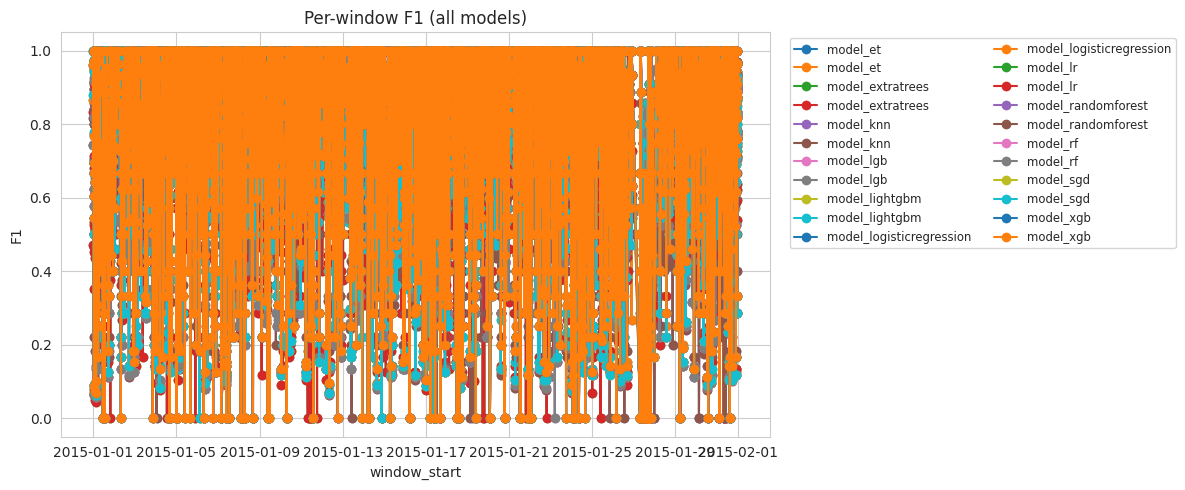

Saved: /mnt/data/stream_results_hf/streaming_visuals/per_window_f1_all_models.png


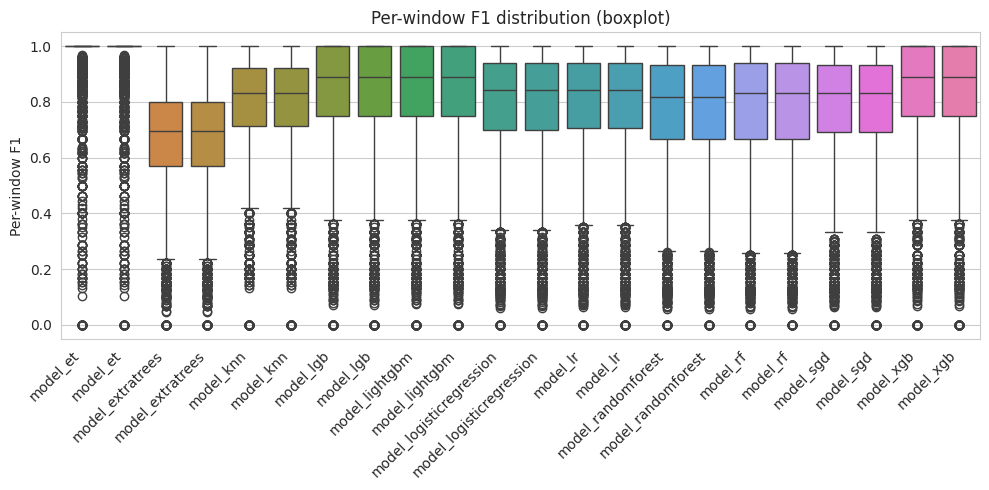

Saved: /mnt/data/stream_results_hf/streaming_visuals/boxplot_per_window_f1_all.png


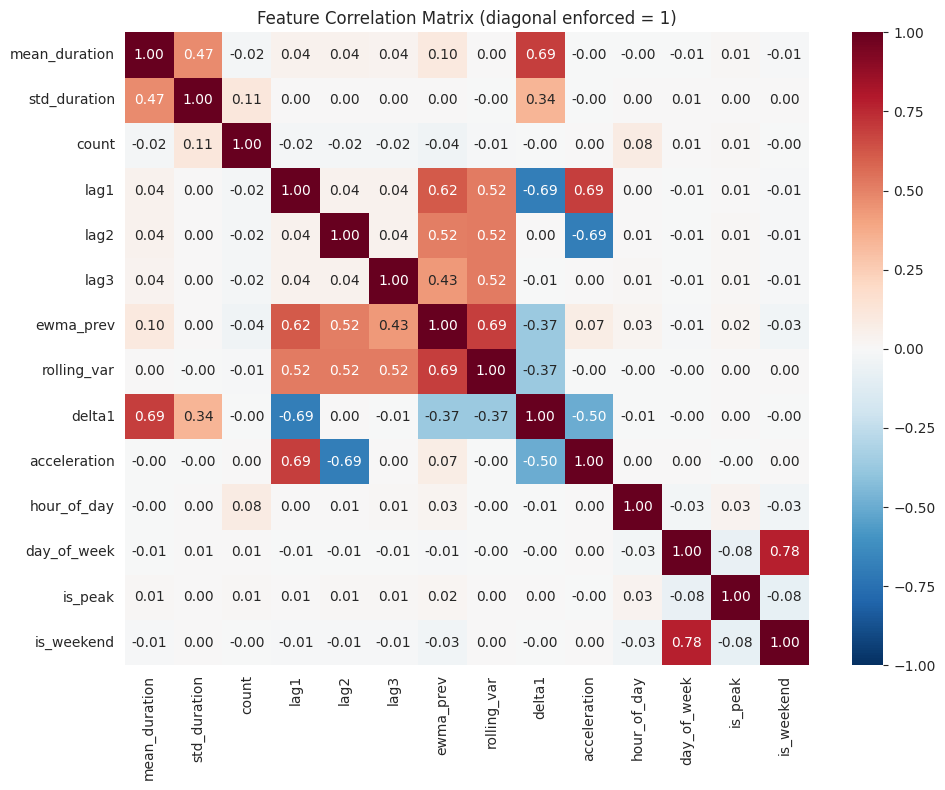

Saved: /mnt/data/stream_results_hf/streaming_visuals/correlation_heatmap.png


In [15]:
# CELL 6: Combined visuals (boxplot, multiline) + correlation heatmap (diag=1)
# Combined per-window F1 multiline
plt.figure(figsize=(12,5))
for mname, col_pred, col_prob in pred_col_names:
    dfw = per_window_f1[mname]
    try:
        idx = pd.to_datetime(dfw['window_start'])
        plt.plot(idx, dfw['f1'], marker='o', linestyle='-', label=mname)
    except:
        plt.plot(dfw['f1'].values, marker='o', linestyle='-', label=mname)
plt.xlabel("window_start"); plt.ylabel("F1")
plt.title("Per-window F1 (all models)")
plt.legend(ncol=2, bbox_to_anchor=(1.02,1), loc='upper left', fontsize='small')
plt.tight_layout()
multi_path = os.path.join(PLOT_DIR, "per_window_f1_all_models.png")
plt.savefig(multi_path, dpi=150, bbox_inches='tight')
plt.show()
print("Saved:", multi_path)

# Boxplot of per-window F1 distributions
plt.figure(figsize=(10,5))
boxdata = [per_window_f1[mname]['f1'].values for mname,_,_ in pred_col_names]
labels = [mname for mname,_,_ in pred_col_names]
sns.boxplot(data=boxdata)
plt.xticks(range(len(labels)), labels, rotation=45, ha='right')
plt.ylabel("Per-window F1")
plt.title("Per-window F1 distribution (boxplot)")
box_path = os.path.join(PLOT_DIR, "boxplot_per_window_f1_all.png")
plt.tight_layout()
plt.savefig(box_path, dpi=150, bbox_inches='tight')
plt.show()
print("Saved:", box_path)

# Correlation heatmap (exclude neighbor if you prefer)
corr_cols = ['mean_duration','std_duration','count','prev_ewma','lag1','lag2','lag3','ewma_prev','rolling_var','delta1','acceleration','hour_of_day','day_of_week','is_peak','is_weekend']
present = [c for c in corr_cols if c in fe.columns]
corr = fe[present].corr()
# ensure diagonal = 1 (it already should be), but force rounding & set diag explicitly
for c in corr.columns:
    corr.loc[c,c] = 1.0

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", vmin=-1, vmax=1)
plt.title("Feature Correlation Matrix (diagonal enforced = 1)")
corr_path = os.path.join(PLOT_DIR, "correlation_heatmap.png")
plt.tight_layout()
plt.savefig(corr_path, dpi=150, bbox_inches='tight')
plt.show()
print("Saved:", corr_path)


In [16]:
# CELL 1: Predict & cache features_with_preds.csv (chunked, memory-friendly)
import os, math, joblib
from pathlib import Path
import numpy as np, pandas as pd

OUT_DIR = "/mnt/data/stream_results_hf"
FEATURES_PATH = os.path.join(OUT_DIR, "features_full.csv")
PRED_SNAPSHOT = os.path.join(OUT_DIR, "streaming_visuals", "features_with_preds.csv")
os.makedirs(os.path.dirname(PRED_SNAPSHOT), exist_ok=True)

FEATURE_COLS = [
    'mean_duration','std_duration','count','lag1','lag2','lag3','ewma_prev',
    'rolling_var','neighbor_mean','delta1','acceleration','hour_of_day',
    'day_of_week','is_peak','is_weekend'
]

# quick checks
if not os.path.exists(FEATURES_PATH):
    raise RuntimeError(f"features_full.csv not found at {FEATURES_PATH}. Run feature-engineering first.")
fe = pd.read_csv(FEATURES_PATH, parse_dates=['window_start'])
print("Loaded features shape:", fe.shape)

# find model files
model_paths = sorted([str(p) for p in Path(OUT_DIR).glob("model_*.pkl")] + [str(p) for p in Path(OUT_DIR).glob("model_*.joblib")])
if len(model_paths) == 0:
    model_paths = sorted([str(p) for p in Path(OUT_DIR).glob("*.pkl")])
print("Model files found:", model_paths)

# load scaler if exists
SCALE_PATH = os.path.join(OUT_DIR, "scaler_allmodels.pkl")
scaler = joblib.load(SCALE_PATH) if os.path.exists(SCALE_PATH) else None

# helper: which models need scaling (heuristic)
SCALE_MODEL_KEYWORDS = ('LogisticRegression','SGD','KNeighbors','KNN','SVC','LinearSVC','SGDClassifier')
def needs_scaling_from_modelobj(m):
    name = m.__class__.__name__.lower()
    for k in SCALE_MODEL_KEYWORDS:
        if k.lower() in name:
            return True
    return False

# If snapshot exists, skip heavy work
if os.path.exists(PRED_SNAPSHOT):
    print("Prediction snapshot already exists at:", PRED_SNAPSHOT)
    fe = pd.read_csv(PRED_SNAPSHOT, parse_dates=['window_start'])
else:
    # ensure feature cols exist
    missing = [c for c in FEATURE_COLS if c not in fe.columns]
    if missing:
        raise RuntimeError("Missing feature columns in features_full.csv: " + ", ".join(missing))

    n_rows = fe.shape[0]
    target_chunk = 100_000   # adjust down if memory constrained
    n_chunks = max(1, math.ceil(n_rows / target_chunk))
    chunk_size = math.ceil(n_rows / n_chunks)
    chunks = [(i, min(i + chunk_size, n_rows)) for i in range(0, n_rows, chunk_size)]
    print(f"Predicting {n_rows} rows in {len(chunks)} chunks (chunk_size ~ {chunk_size})")

    X_all = fe[FEATURE_COLS].values.astype(np.float32)

    for mpath in model_paths:
        try:
            model = joblib.load(mpath)
        except Exception as e:
            print(f"Could not load model {mpath}: {e}; skipping.")
            continue
        mname = Path(mpath).stem
        col_pred = f"y_pred__{mname}"
        col_prob = f"y_prob__{mname}"

        # prepare arrays
        y_preds = np.empty(n_rows, dtype=np.int8)
        y_probs = np.full(n_rows, np.nan, dtype=float)

        use_scaler = (scaler is not None and needs_scaling_from_modelobj(model))

        for idx0, idx1 in chunks:
            Xchunk = X_all[idx0:idx1]
            Xinp = scaler.transform(Xchunk) if use_scaler else Xchunk
            # predict
            try:
                yp = model.predict(Xinp)
            except Exception as e:
                print(f"Predict error for {mname} chunk {idx0}:{idx1}: {e}; using zeros fallback.")
                yp = np.zeros(Xinp.shape[0], dtype=int)
            y_preds[idx0:idx1] = yp

            # probs if available
            if hasattr(model, "predict_proba"):
                try:
                    yp_prob = model.predict_proba(Xinp)[:,1]
                    y_probs[idx0:idx1] = yp_prob
                except Exception:
                    pass

        fe[col_pred] = y_preds
        fe[col_prob] = y_probs
        print("Added columns for model:", mname)

    fe.to_csv(PRED_SNAPSHOT, index=False)
    print("Saved features_with_preds snapshot to:", PRED_SNAPSHOT)

print("Done. Next: plotting (run Cell 2).")


Loaded features shape: (159022, 18)
Model files found: ['/mnt/data/stream_results_hf/model_et.pkl', '/mnt/data/stream_results_hf/model_extratrees.pkl', '/mnt/data/stream_results_hf/model_knn.pkl', '/mnt/data/stream_results_hf/model_lgb.pkl', '/mnt/data/stream_results_hf/model_lightgbm.pkl', '/mnt/data/stream_results_hf/model_logisticregression.pkl', '/mnt/data/stream_results_hf/model_lr.pkl', '/mnt/data/stream_results_hf/model_randomforest.pkl', '/mnt/data/stream_results_hf/model_rf.pkl', '/mnt/data/stream_results_hf/model_sgd.pkl', '/mnt/data/stream_results_hf/model_xgb.pkl']
Prediction snapshot already exists at: /mnt/data/stream_results_hf/streaming_visuals/features_with_preds.csv
Done. Next: plotting (run Cell 2).


In [20]:
# CELL 2 (REPLACED): Per-model per-window F1 line plots + per-model ROC plots (separate files)
import os, math, joblib
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.metrics import roc_curve, auc, f1_score, accuracy_score

OUT_DIR = "/mnt/data/stream_results_hf"
PRED_SNAPSHOT = os.path.join(OUT_DIR, "streaming_visuals", "features_with_preds.csv")
PLOT_DIR = os.path.join(OUT_DIR, "streaming_visuals")
os.makedirs(PLOT_DIR, exist_ok=True)

FEATURE_COLS = [
    'mean_duration','std_duration','count','lag1','lag2','lag3','ewma_prev',
    'rolling_var','neighbor_mean','delta1','acceleration','hour_of_day',
    'day_of_week','is_peak','is_weekend'
]

# Load dataset with predictions (created by Cell 1)
if not os.path.exists(PRED_SNAPSHOT):
    raise RuntimeError("Run Cell 1 first to generate predictions (features_with_preds.csv).")
fe = pd.read_csv(PRED_SNAPSHOT, parse_dates=['window_start'])
print("Loaded features_with_preds shape:", fe.shape)

# discover models by prediction columns
pred_cols = sorted([c for c in fe.columns if c.startswith("y_pred__")])
model_names = [c.replace("y_pred__", "") for c in pred_cols]
print("Models available:", model_names)
if len(model_names) == 0:
    raise RuntimeError("No prediction columns found in features_with_preds.csv. Run Cell 1 to produce them.")

# windows ordering
windows = sorted(fe['window_start'].unique())

# containers for summary
summary_rows = []

# loop models -> create separate plots + CSVs
for m in model_names:
    print("\nProcessing model:", m)
    col_pred = f"y_pred__{m}"
    col_prob = f"y_prob__{m}"
    win_rows = []
    y_true_all, y_pred_all, y_prob_all = [], [], []

    # compute per-window F1
    for w in windows:
        cur = fe[fe['window_start'] == w]
        if cur.shape[0] == 0:
            continue
        ytrue = cur['label'].values
        ypred = cur[col_pred].values
        # if probability column present use it else NaNs
        if col_prob in cur.columns:
            yprob = cur[col_prob].values
        else:
            yprob = np.array([np.nan]*len(ytrue))
        f1 = f1_score(ytrue, ypred, zero_division=0)
        win_rows.append((w, float(f1)))
        y_true_all.extend(ytrue.tolist())
        y_pred_all.extend(ypred.tolist())
        y_prob_all.extend([float(x) if not pd.isna(x) else np.nan for x in yprob.tolist()])

    # save per-window csv for this model
    df_win = pd.DataFrame(win_rows, columns=['window_start','f1']).set_index('window_start')
    csv_win_path = os.path.join(PLOT_DIR, f"window_f1_{m}.csv")
    df_win.to_csv(csv_win_path)
    print("Saved per-window F1 CSV:", csv_win_path)

    # PLOT 1: per-window F1 line (single model)
    plt.figure(figsize=(10,4))
    if df_win.shape[0] > 0:
        try:
            idx = pd.to_datetime(df_win.index)
        except:
            idx = df_win.index
        plt.plot(idx, df_win['f1'], marker='o', linestyle='-')
    plt.xlabel("window_start")
    plt.ylabel("Per-window F1")
    plt.title(f"Per-window F1 over time — {m}")
    plt.grid(alpha=0.25)
    plt.tight_layout()
    line_out = os.path.join(PLOT_DIR, f"per_window_f1_{m}.png")
    plt.savefig(line_out, dpi=150, bbox_inches='tight')
    plt.close()
    print("Saved per-window F1 plot:", line_out)

    # POOLED METRICS: accuracy, f1
    y_true_arr = np.array(y_true_all, dtype=int) if len(y_true_all)>0 else np.array([], dtype=int)
    y_pred_arr = np.array(y_pred_all, dtype=int) if len(y_pred_all)>0 else np.array([], dtype=int)
    y_prob_arr = np.array(y_prob_all, dtype=float) if len(y_prob_all)>0 else np.array([], dtype=float)

    if y_true_arr.size == 0:
        print("No pooled samples for model:", m)
        continue

    pooled_f1 = float(f1_score(y_true_arr, y_pred_arr, zero_division=0))
    pooled_acc = float(accuracy_score(y_true_arr, y_pred_arr))

    # save summary row
    summary_rows.append({'model': m, 'f1': pooled_f1, 'accuracy': pooled_acc})

    # PLOT 2: ROC (if probability info exists)
    if not np.isnan(y_prob_arr).all():
        mask = ~np.isnan(y_prob_arr)
        if mask.sum() > 0 and len(np.unique(y_true_arr[mask])) > 1:
            try:
                fpr, tpr, _ = roc_curve(y_true_arr[mask], y_prob_arr[mask])
                roc_auc_val = auc(fpr, tpr)
                plt.figure(figsize=(6,5))
                plt.plot(fpr, tpr, label=f"AUC={roc_auc_val:.3f}")
                plt.plot([0,1],[0,1],'--', color='gray')
                plt.xlabel("False Positive Rate")
                plt.ylabel("True Positive Rate")
                plt.title(f"ROC Curve (pooled) — {m}")
                plt.legend(loc='lower right')
                plt.grid(alpha=0.25)
                plt.tight_layout()
                roc_out = os.path.join(PLOT_DIR, f"roc_{m}.png")
                plt.savefig(roc_out, dpi=150, bbox_inches='tight')
                plt.close()
                print("Saved ROC plot:", roc_out)
            except Exception as e:
                print("ROC plot error for", m, ":", e)
        else:
            print("Not enough class variety or probability values to compute ROC for", m)
    else:
        print("No probability outputs for model; skipping ROC for", m)

# write summary table
summary_df = pd.DataFrame(summary_rows).sort_values('f1', ascending=False).reset_index(drop=True)
summary_path = os.path.join(PLOT_DIR, "model_summary_table.csv")
summary_df.to_csv(summary_path, index=False)
print("\nSaved model summary table to:", summary_path)
print(summary_df)


Loaded features_with_preds shape: (159022, 40)
Models available: ['model_et', 'model_extratrees', 'model_knn', 'model_lgb', 'model_lightgbm', 'model_logisticregression', 'model_lr', 'model_randomforest', 'model_rf', 'model_sgd', 'model_xgb']

Processing model: model_et
Saved per-window F1 CSV: /mnt/data/stream_results_hf/streaming_visuals/window_f1_model_et.csv
Saved per-window F1 plot: /mnt/data/stream_results_hf/streaming_visuals/per_window_f1_model_et.png
Saved ROC plot: /mnt/data/stream_results_hf/streaming_visuals/roc_model_et.png

Processing model: model_extratrees
Saved per-window F1 CSV: /mnt/data/stream_results_hf/streaming_visuals/window_f1_model_extratrees.csv
Saved per-window F1 plot: /mnt/data/stream_results_hf/streaming_visuals/per_window_f1_model_extratrees.png
Saved ROC plot: /mnt/data/stream_results_hf/streaming_visuals/roc_model_extratrees.png

Processing model: model_knn
Saved per-window F1 CSV: /mnt/data/stream_results_hf/streaming_visuals/window_f1_model_knn.csv
Sa

Loaded: /mnt/data/stream_results_hf/streaming_visuals/features_with_preds.csv shape: (159022, 40)
Using pred column: y_pred__model_extratrees prob column: y_prob__model_extratrees
Per-window points: 4048


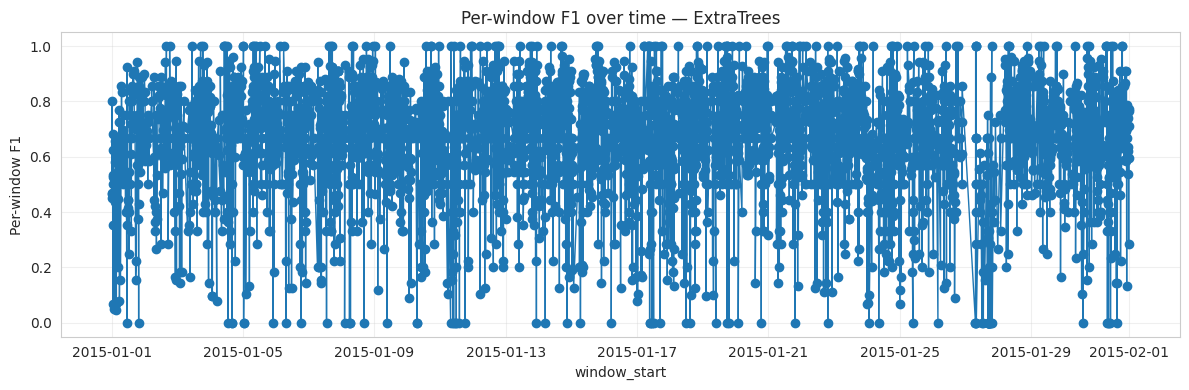

Pooled metrics — ExtraTrees: Accuracy = 0.8571, F1 = 0.6707, samples = 159022


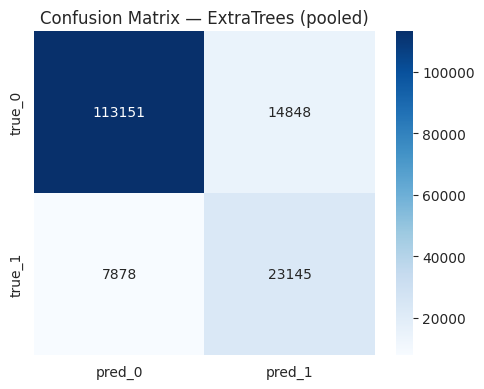

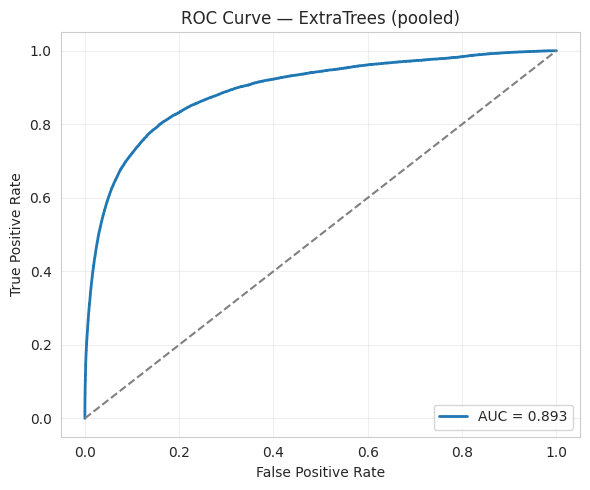

In [21]:
# CELL: Display per-window line plot + ROC + confusion matrix for ExtraTrees (inline)
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import f1_score, accuracy_score, roc_curve, auc, confusion_matrix

PRED_SNAPSHOT = "/mnt/data/stream_results_hf/streaming_visuals/features_with_preds.csv"
MODEL_KEY = "model_extratrees"   # adjust if your prediction column uses a slightly different name

if not os.path.exists(PRED_SNAPSHOT):
    raise FileNotFoundError(f"Predictions snapshot not found at: {PRED_SNAPSHOT}")

# load predictions with features
fe = pd.read_csv(PRED_SNAPSHOT, parse_dates=['window_start'])
print("Loaded:", PRED_SNAPSHOT, "shape:", fe.shape)

# discover actual model pred/prob columns for ExtraTrees (robust lookup)
pred_col = None
prob_col = None
for c in fe.columns:
    if c.lower().startswith("y_pred__") and MODEL_KEY.lower() in c.lower():
        pred_col = c
    if c.lower().startswith("y_prob__") and MODEL_KEY.lower() in c.lower():
        prob_col = c

if pred_col is None:
    # try exact column name fallback
    if f"y_pred__{MODEL_KEY}" in fe.columns:
        pred_col = f"y_pred__{MODEL_KEY}"
    else:
        raise RuntimeError("Could not find predicted label column for ExtraTrees in features_with_preds.csv. Columns found: " + ", ".join([c for c in fe.columns if c.startswith("y_pred__")]))

print("Using pred column:", pred_col, "prob column:", prob_col)

# windows
windows = sorted(fe['window_start'].unique())

# compute per-window F1s
win_rows = []
y_true_all, y_pred_all, y_prob_all = [], [], []

for w in windows:
    cur = fe[fe['window_start'] == w]
    if cur.shape[0] == 0:
        continue
    ytrue = cur['label'].values
    ypred = cur[pred_col].values
    if prob_col and prob_col in cur.columns:
        yprob = cur[prob_col].values
    else:
        yprob = np.array([np.nan]*len(ytrue))
    f1 = f1_score(ytrue, ypred, zero_division=0)
    win_rows.append((w, float(f1)))
    y_true_all.extend(ytrue.tolist())
    y_pred_all.extend(ypred.tolist())
    y_prob_all.extend([float(x) if not pd.isna(x) else np.nan for x in yprob.tolist()])

df_win = pd.DataFrame(win_rows, columns=['window_start','f1']).set_index('window_start')
print("Per-window points:", df_win.shape[0])

# inline: per-window F1 line plot
plt.figure(figsize=(12,4))
if df_win.shape[0] > 0:
    try:
        idx = pd.to_datetime(df_win.index)
    except:
        idx = df_win.index
    plt.plot(idx, df_win['f1'], marker='o', linestyle='-', linewidth=1)
plt.xlabel("window_start")
plt.ylabel("Per-window F1")
plt.title("Per-window F1 over time — ExtraTrees")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# pooled metrics
y_true = np.array(y_true_all, dtype=int)
y_pred = np.array(y_pred_all, dtype=int)
y_prob = np.array(y_prob_all, dtype=float)

pooled_f1 = f1_score(y_true, y_pred, zero_division=0)
pooled_acc = accuracy_score(y_true, y_pred)
print(f"Pooled metrics — ExtraTrees: Accuracy = {pooled_acc:.4f}, F1 = {pooled_f1:.4f}, samples = {len(y_true)}")

# confusion matrix heatmap
cm = confusion_matrix(y_true, y_pred)
cm_df = pd.DataFrame(cm, index=["true_0","true_1"], columns=["pred_0","pred_1"])
plt.figure(figsize=(5,4))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix — ExtraTrees (pooled)")
plt.tight_layout()
plt.show()

# ROC curve (only if probability outputs exist)
if not np.isnan(y_prob).all():
    mask = ~np.isnan(y_prob)
    if mask.sum() > 0 and len(np.unique(y_true[mask])) > 1:
        fpr, tpr, _ = roc_curve(y_true[mask], y_prob[mask])
        roc_auc_val = auc(fpr, tpr)
        plt.figure(figsize=(6,5))
        plt.plot(fpr, tpr, lw=2, label=f"AUC = {roc_auc_val:.3f}")
        plt.plot([0,1],[0,1],'--', color='gray')
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title("ROC Curve — ExtraTrees (pooled)")
        plt.legend(loc='lower right')
        plt.grid(alpha=0.3)
        plt.tight_layout()
        plt.show()
    else:
        print("Not enough variety in classes to compute ROC (after masking NaNs).")
else:
    print("No probability outputs for ExtraTrees (y_prob column missing or all NaN).")


Loaded features_with_preds shape: (159022, 40)
Best model by pooled F1: model_et F1= 0.964489188139324


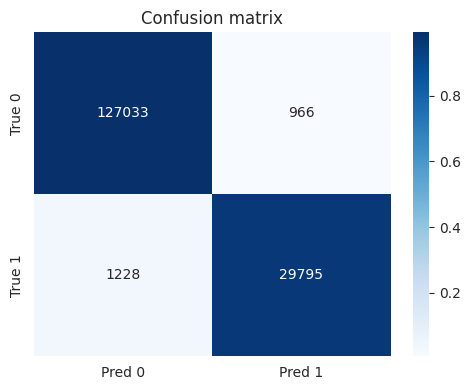

Saved confusion heatmap to: /mnt/data/stream_results_hf/streaming_visuals/confusion_heatmap_model_et.png


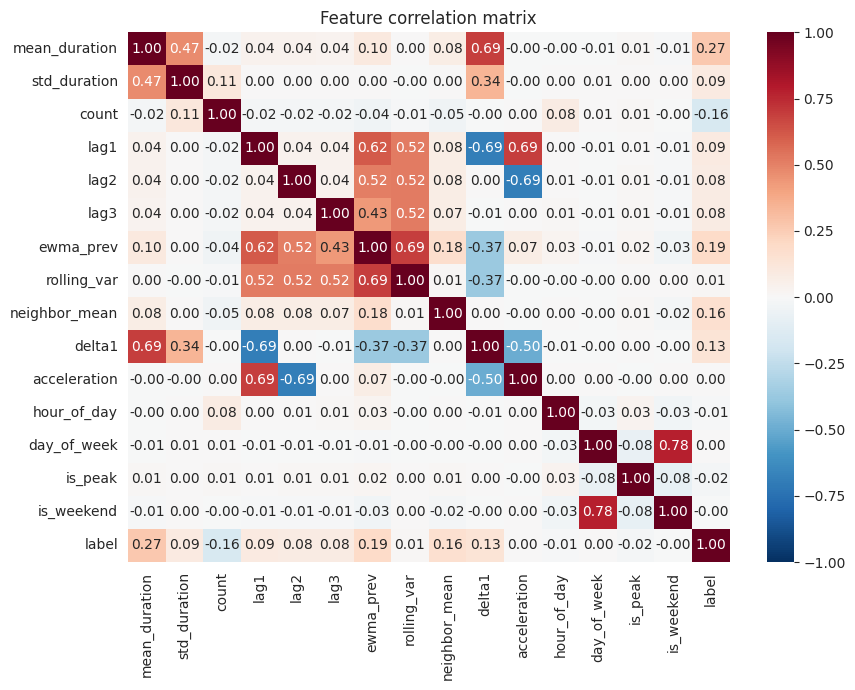

Saved feature correlation heatmap to: /mnt/data/stream_results_hf/streaming_visuals/feature_correlation_heatmap.png
All visuals saved under: /mnt/data/stream_results_hf/streaming_visuals


In [19]:
# CELL 3: Confusion heatmap for best model (pooled) and feature correlation heatmap
import os, joblib
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.metrics import confusion_matrix, f1_score

OUT_DIR = "/mnt/data/stream_results_hf"
PRED_SNAPSHOT = os.path.join(OUT_DIR, "streaming_visuals", "features_with_preds.csv")
PLOT_DIR = os.path.join(OUT_DIR, "streaming_visuals")
os.makedirs(PLOT_DIR, exist_ok=True)

FEATURE_COLS = [
    'mean_duration','std_duration','count','lag1','lag2','lag3','ewma_prev',
    'rolling_var','neighbor_mean','delta1','acceleration','hour_of_day',
    'day_of_week','is_peak','is_weekend'
]

# load
if not os.path.exists(PRED_SNAPSHOT):
    raise RuntimeError("Run Cell 1 first to generate predictions (features_with_preds.csv).")
fe = pd.read_csv(PRED_SNAPSHOT, parse_dates=['window_start'])
print("Loaded features_with_preds shape:", fe.shape)

# find models
pred_cols = [c for c in fe.columns if c.startswith("y_pred__")]
model_names = [c.replace("y_pred__", "") for c in pred_cols]
if len(model_names)==0:
    raise RuntimeError("No prediction columns found. Run Cell 1.")

# compute pooled F1 per model and choose best
best_model = None
best_f1 = -1
pooled = {}
for m in model_names:
    y_true = fe['label'].values
    y_pred = fe[f"y_pred__{m}"].values
    f1 = f1_score(y_true, y_pred, zero_division=0)
    pooled[m] = (y_true, y_pred)
    if f1 > best_f1:
        best_f1 = f1
        best_model = m
print("Best model by pooled F1:", best_model, "F1=", best_f1)

# Confusion matrix (counts + normalized rows) for best model
y_true, y_pred = pooled[best_model]
cm = confusion_matrix(y_true, y_pred)
cm_norm = cm.astype(float) / (cm.sum(axis=1, keepdims=True) + 1e-12)

fig, ax = plt.subplots(figsize=(5,4))
sns.heatmap(cm_norm, annot=cm, fmt='g', cmap='Blues', xticklabels=['Pred 0','Pred 1'], yticklabels=['True 0','True 1'], ax=ax)
ax.set_title(f"Confusion matrix")
plt.tight_layout()
cm_out = os.path.join(PLOT_DIR, f"confusion_heatmap_{best_model}.png")
plt.savefig(cm_out, dpi=150, bbox_inches='tight')
plt.show()
print("Saved confusion heatmap to:", cm_out)

# Feature correlation heatmap (including label) — diagonal will be 1 naturally
missing = [c for c in FEATURE_COLS if c not in fe.columns]
if missing:
    print("Warning: some feature columns missing for correlation plot:", missing)
else:
    corr_df = fe[FEATURE_COLS + ['label']].corr()
    fig, ax = plt.subplots(figsize=(9,7))
    sns.heatmap(corr_df, annot=True, fmt=".2f", cmap="RdBu_r", vmin=-1, vmax=1, ax=ax)
    ax.set_title("Feature correlation matrix")
    corr_out = os.path.join(PLOT_DIR, "feature_correlation_heatmap.png")
    plt.tight_layout()
    plt.savefig(corr_out, dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved feature correlation heatmap to:", corr_out)

print("All visuals saved under:", PLOT_DIR)


Loaded: /mnt/data/stream_results_hf/streaming_visuals/features_with_preds.csv shape: (159022, 40)
Found models: ['model_et', 'model_extratrees', 'model_knn', 'model_lgb', 'model_lightgbm', 'model_logisticregression', 'model_lr', 'model_randomforest', 'model_rf', 'model_sgd', 'model_xgb']


=== MODEL: model_et ===



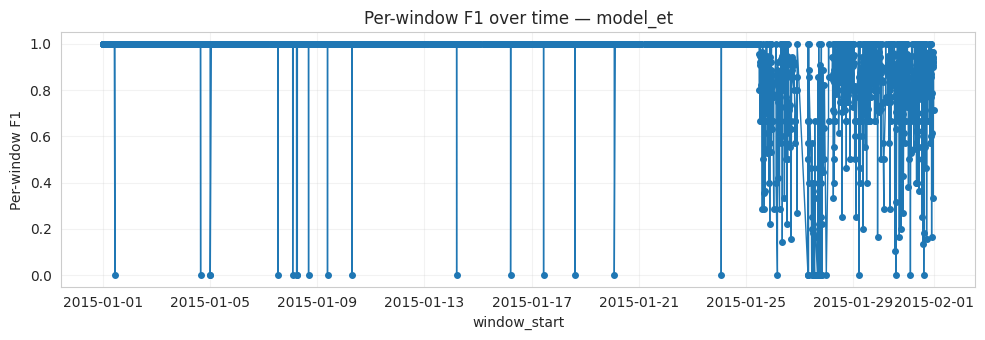

Saved per-window F1 PNG to: /mnt/data/stream_results_hf/streaming_visuals/per_window_f1_model_et.png
Pooled metrics — model_et: Accuracy = 0.9862, F1 = 0.9645, samples = 159022


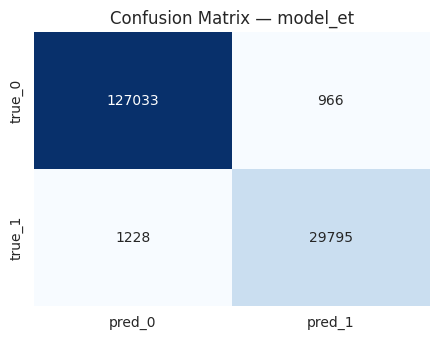

Saved confusion matrix PNG to: /mnt/data/stream_results_hf/streaming_visuals/confusion_matrix_model_et.png


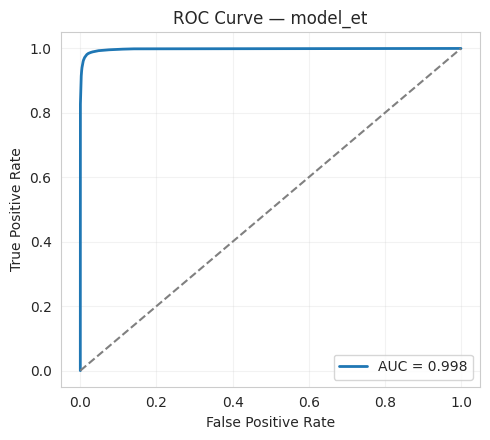

Saved ROC PNG to: /mnt/data/stream_results_hf/streaming_visuals/roc_model_et.png


=== MODEL: model_extratrees ===



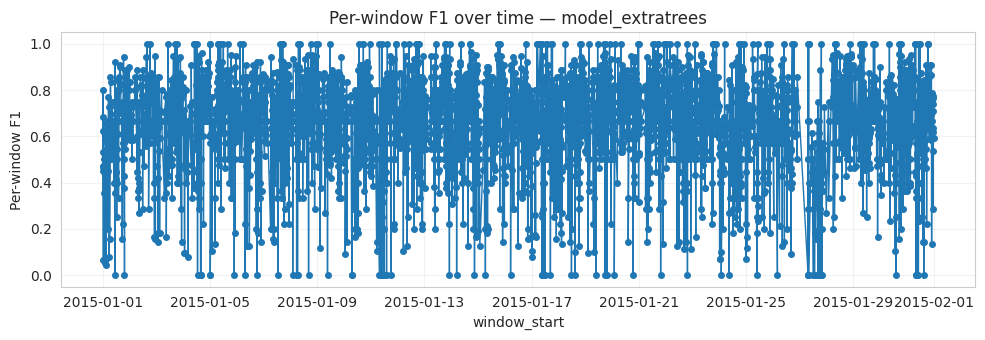

Saved per-window F1 PNG to: /mnt/data/stream_results_hf/streaming_visuals/per_window_f1_model_extratrees.png
Pooled metrics — model_extratrees: Accuracy = 0.8571, F1 = 0.6707, samples = 159022


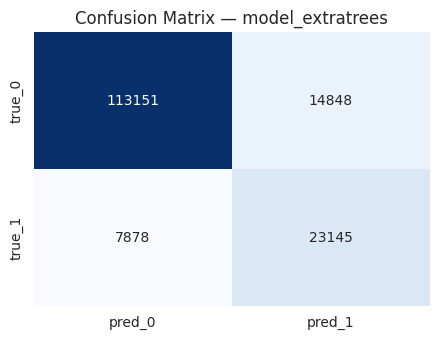

Saved confusion matrix PNG to: /mnt/data/stream_results_hf/streaming_visuals/confusion_matrix_model_extratrees.png


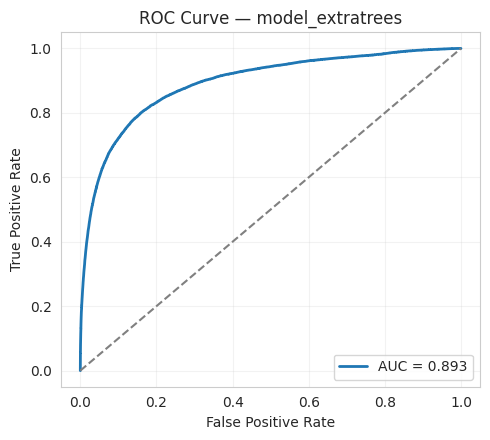

Saved ROC PNG to: /mnt/data/stream_results_hf/streaming_visuals/roc_model_extratrees.png


=== MODEL: model_knn ===



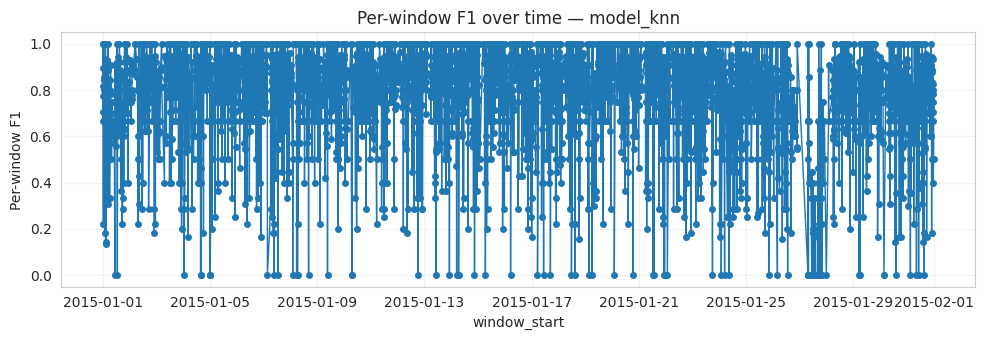

Saved per-window F1 PNG to: /mnt/data/stream_results_hf/streaming_visuals/per_window_f1_model_knn.png
Pooled metrics — model_knn: Accuracy = 0.9314, F1 = 0.8100, samples = 159022


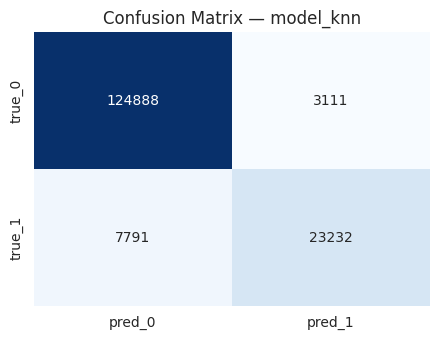

Saved confusion matrix PNG to: /mnt/data/stream_results_hf/streaming_visuals/confusion_matrix_model_knn.png


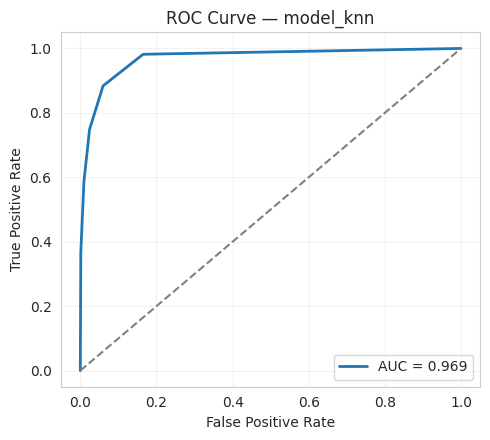

Saved ROC PNG to: /mnt/data/stream_results_hf/streaming_visuals/roc_model_knn.png


=== MODEL: model_lgb ===



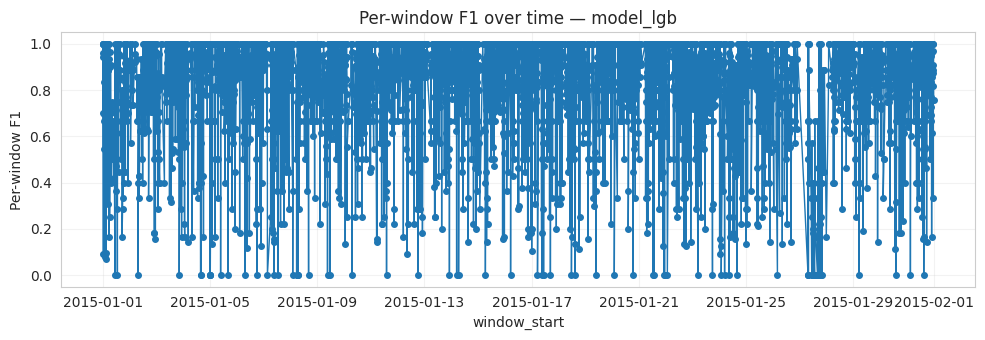

Saved per-window F1 PNG to: /mnt/data/stream_results_hf/streaming_visuals/per_window_f1_model_lgb.png
Pooled metrics — model_lgb: Accuracy = 0.9396, F1 = 0.8461, samples = 159022


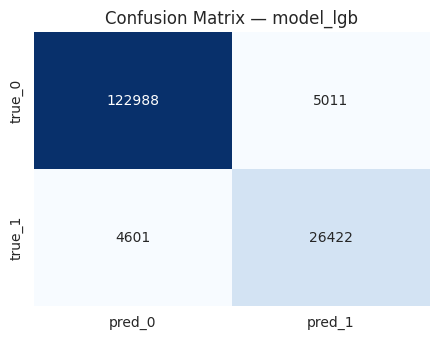

Saved confusion matrix PNG to: /mnt/data/stream_results_hf/streaming_visuals/confusion_matrix_model_lgb.png


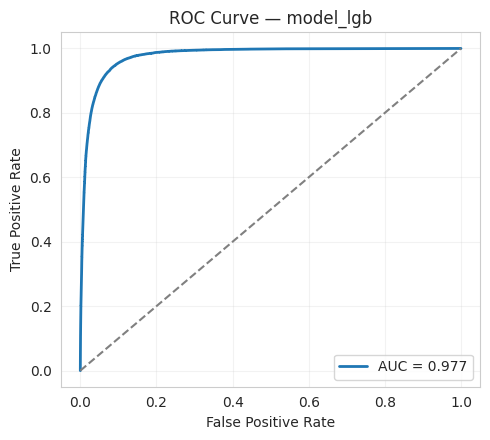

Saved ROC PNG to: /mnt/data/stream_results_hf/streaming_visuals/roc_model_lgb.png


=== MODEL: model_lightgbm ===



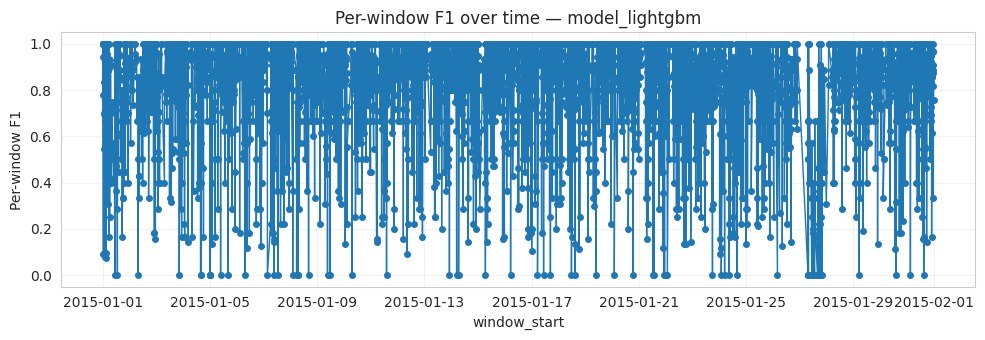

Saved per-window F1 PNG to: /mnt/data/stream_results_hf/streaming_visuals/per_window_f1_model_lightgbm.png
Pooled metrics — model_lightgbm: Accuracy = 0.9402, F1 = 0.8481, samples = 159022


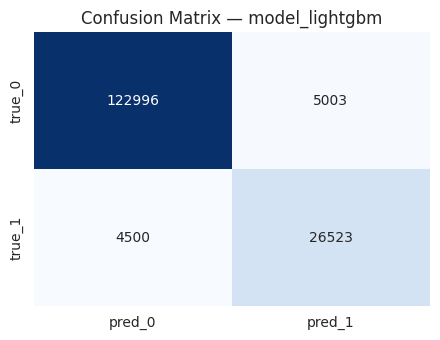

Saved confusion matrix PNG to: /mnt/data/stream_results_hf/streaming_visuals/confusion_matrix_model_lightgbm.png


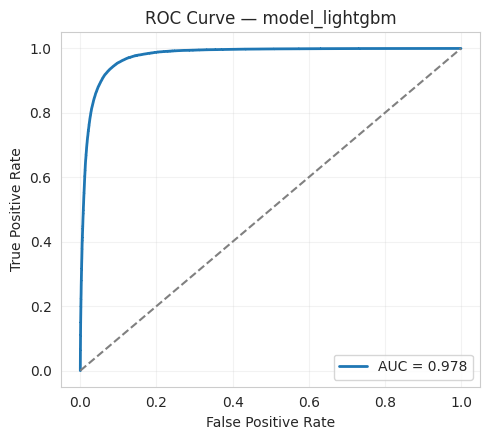

Saved ROC PNG to: /mnt/data/stream_results_hf/streaming_visuals/roc_model_lightgbm.png


=== MODEL: model_logisticregression ===



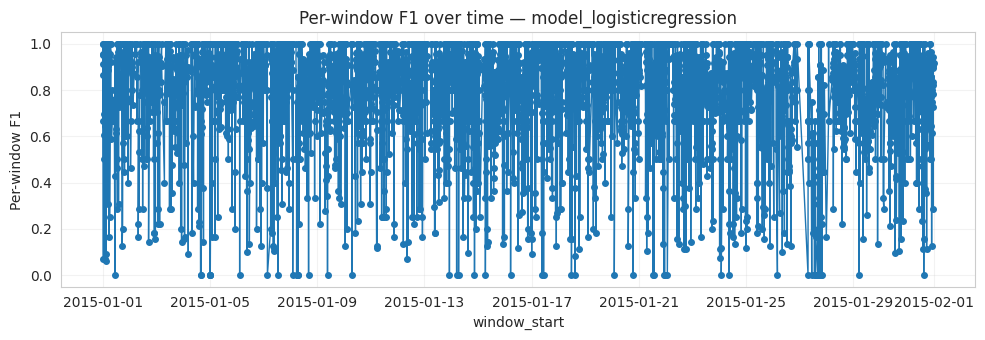

Saved per-window F1 PNG to: /mnt/data/stream_results_hf/streaming_visuals/per_window_f1_model_logisticregression.png
Pooled metrics — model_logisticregression: Accuracy = 0.9106, F1 = 0.7989, samples = 159022


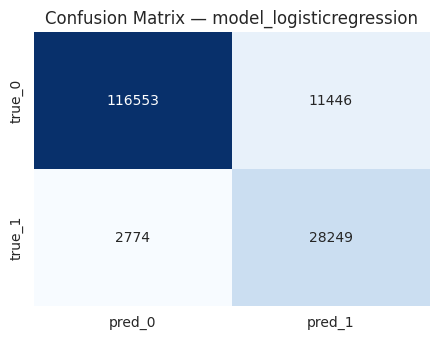

Saved confusion matrix PNG to: /mnt/data/stream_results_hf/streaming_visuals/confusion_matrix_model_logisticregression.png


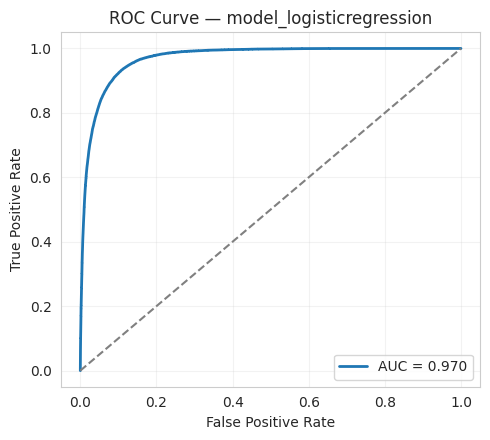

Saved ROC PNG to: /mnt/data/stream_results_hf/streaming_visuals/roc_model_logisticregression.png


=== MODEL: model_lr ===



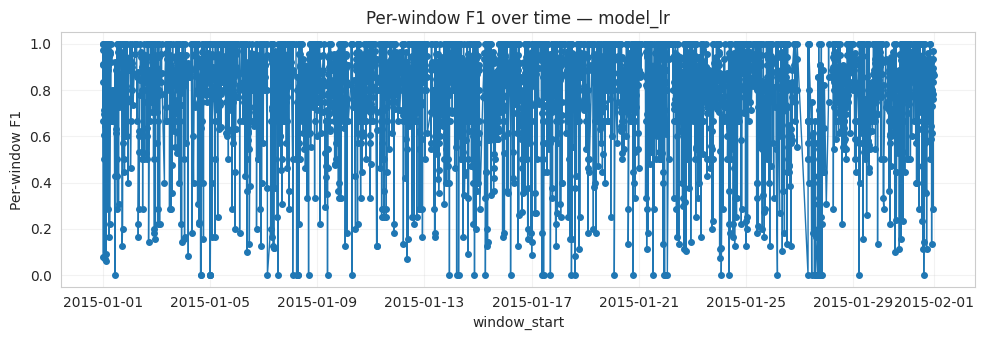

Saved per-window F1 PNG to: /mnt/data/stream_results_hf/streaming_visuals/per_window_f1_model_lr.png
Pooled metrics — model_lr: Accuracy = 0.9111, F1 = 0.7989, samples = 159022


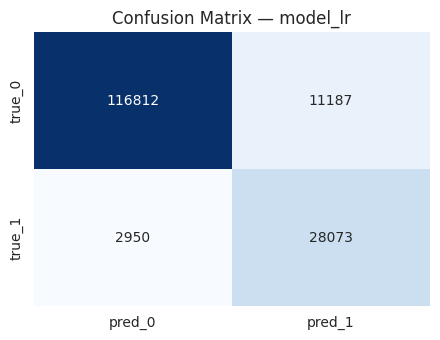

Saved confusion matrix PNG to: /mnt/data/stream_results_hf/streaming_visuals/confusion_matrix_model_lr.png


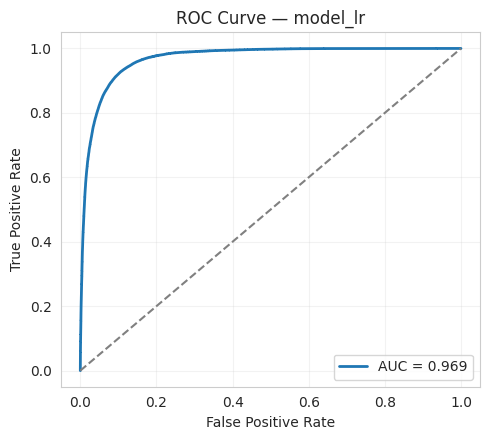

Saved ROC PNG to: /mnt/data/stream_results_hf/streaming_visuals/roc_model_lr.png


=== MODEL: model_randomforest ===



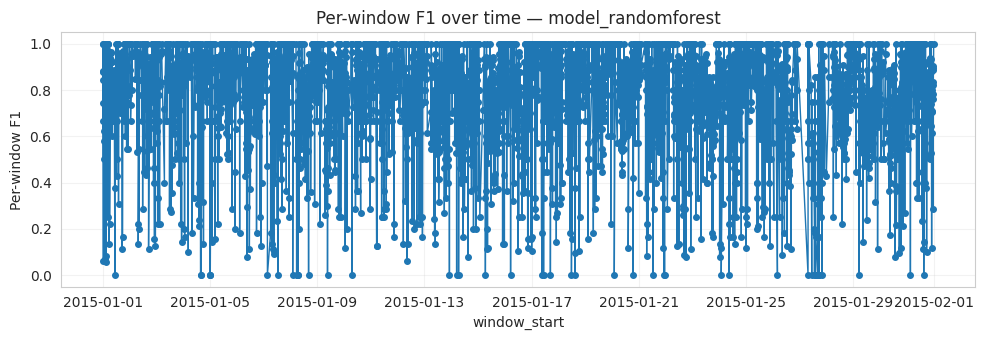

Saved per-window F1 PNG to: /mnt/data/stream_results_hf/streaming_visuals/per_window_f1_model_randomforest.png
Pooled metrics — model_randomforest: Accuracy = 0.8940, F1 = 0.7755, samples = 159022


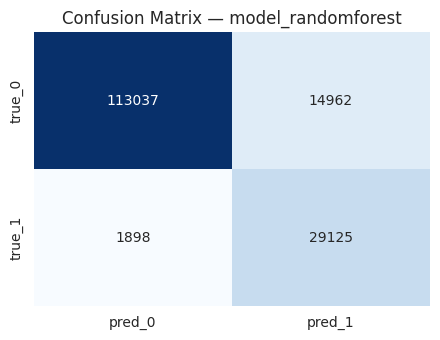

Saved confusion matrix PNG to: /mnt/data/stream_results_hf/streaming_visuals/confusion_matrix_model_randomforest.png


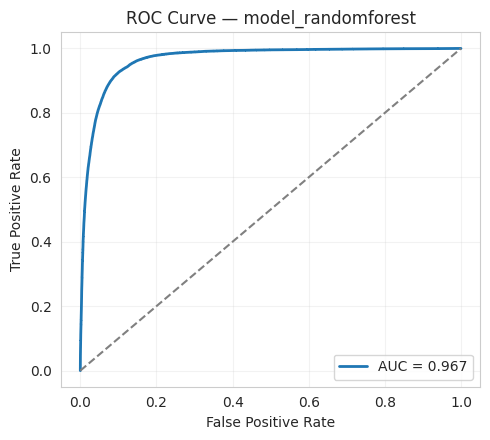

Saved ROC PNG to: /mnt/data/stream_results_hf/streaming_visuals/roc_model_randomforest.png


=== MODEL: model_rf ===



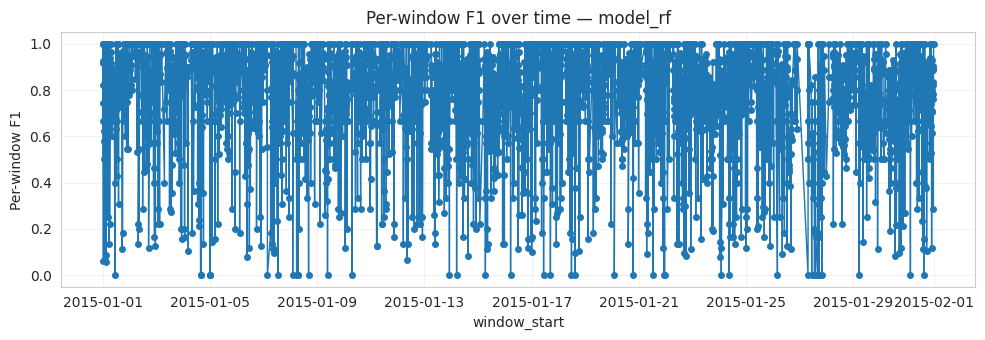

Saved per-window F1 PNG to: /mnt/data/stream_results_hf/streaming_visuals/per_window_f1_model_rf.png
Pooled metrics — model_rf: Accuracy = 0.9006, F1 = 0.7872, samples = 159022


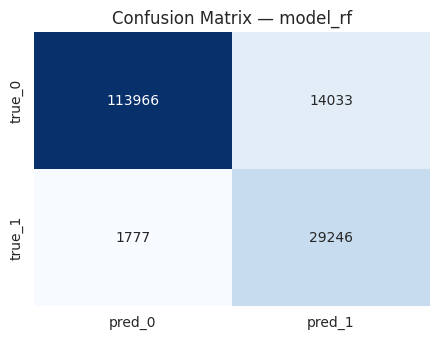

Saved confusion matrix PNG to: /mnt/data/stream_results_hf/streaming_visuals/confusion_matrix_model_rf.png


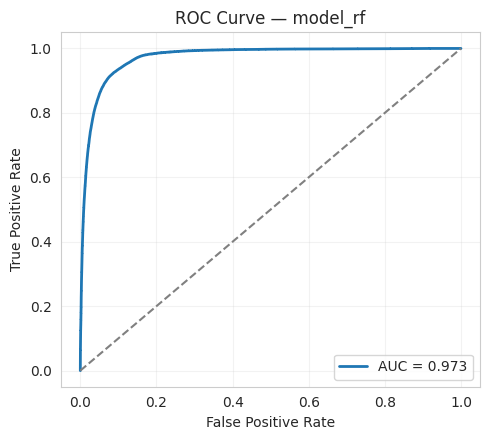

Saved ROC PNG to: /mnt/data/stream_results_hf/streaming_visuals/roc_model_rf.png


=== MODEL: model_sgd ===



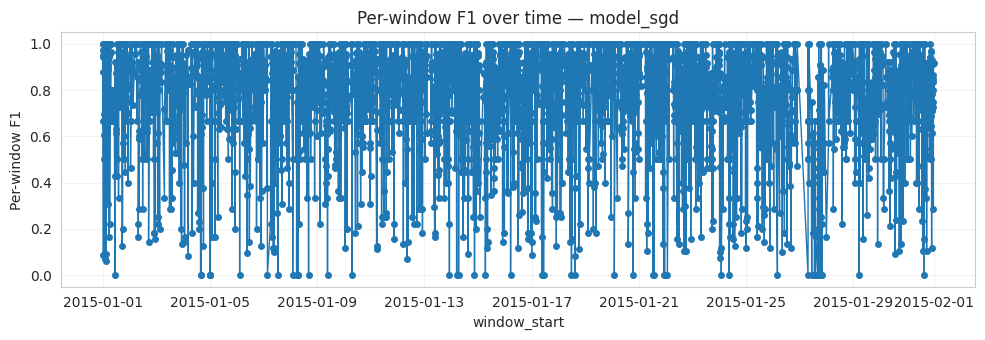

Saved per-window F1 PNG to: /mnt/data/stream_results_hf/streaming_visuals/per_window_f1_model_sgd.png
Pooled metrics — model_sgd: Accuracy = 0.9073, F1 = 0.7931, samples = 159022


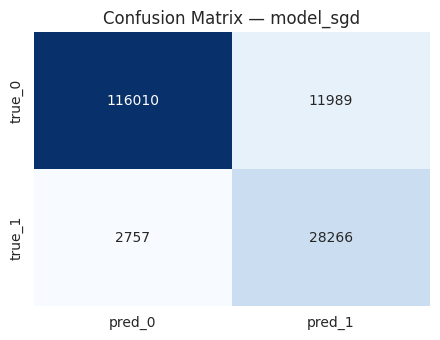

Saved confusion matrix PNG to: /mnt/data/stream_results_hf/streaming_visuals/confusion_matrix_model_sgd.png


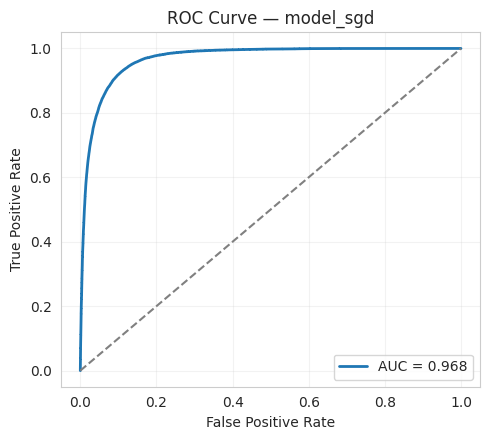

Saved ROC PNG to: /mnt/data/stream_results_hf/streaming_visuals/roc_model_sgd.png


=== MODEL: model_xgb ===



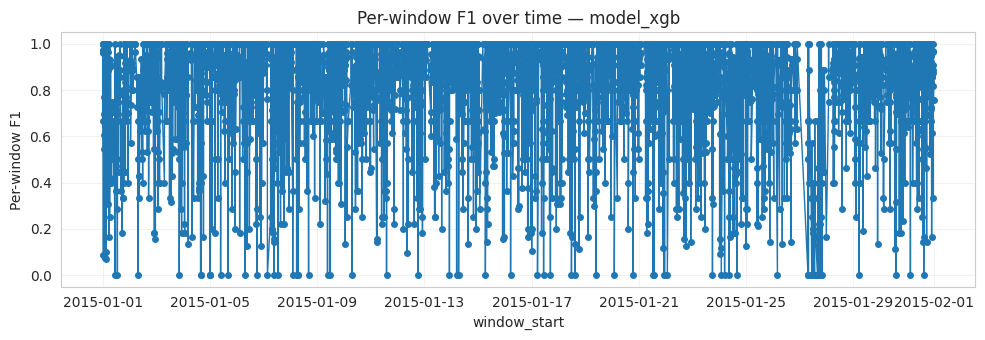

Saved per-window F1 PNG to: /mnt/data/stream_results_hf/streaming_visuals/per_window_f1_model_xgb.png
Pooled metrics — model_xgb: Accuracy = 0.9409, F1 = 0.8489, samples = 159022


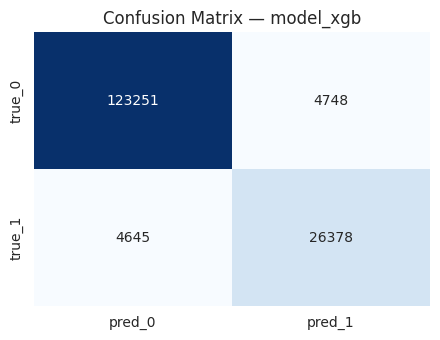

Saved confusion matrix PNG to: /mnt/data/stream_results_hf/streaming_visuals/confusion_matrix_model_xgb.png


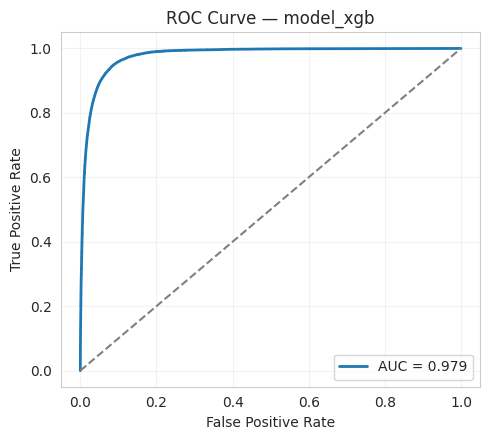

Saved ROC PNG to: /mnt/data/stream_results_hf/streaming_visuals/roc_model_xgb.png

All model visualizations completed. PNGs saved under: /mnt/data/stream_results_hf/streaming_visuals


In [22]:
# CELL: Display per-window F1, confusion matrix, and ROC for ALL models (inline + save PNGs)
import os, math
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.metrics import f1_score, accuracy_score, confusion_matrix, roc_curve, auc

PRED_SNAPSHOT = "/mnt/data/stream_results_hf/streaming_visuals/features_with_preds.csv"
OUT_PLOT_DIR = "/mnt/data/stream_results_hf/streaming_visuals"
os.makedirs(OUT_PLOT_DIR, exist_ok=True)

if not os.path.exists(PRED_SNAPSHOT):
    raise FileNotFoundError(f"Predictions snapshot not found at: {PRED_SNAPSHOT}")

# Load snapshot with predictions & probs
fe = pd.read_csv(PRED_SNAPSHOT, parse_dates=['window_start'])
print("Loaded:", PRED_SNAPSHOT, "shape:", fe.shape)

# discover models by looking for y_pred__* columns
pred_cols = sorted([c for c in fe.columns if c.startswith("y_pred__")])
if len(pred_cols) == 0:
    raise RuntimeError("No prediction columns found. Ensure features_with_preds.csv contains columns like 'y_pred__<modelname>'")

model_names = [c.replace("y_pred__", "") for c in pred_cols]
print("Found models:", model_names)

# order windows
windows = sorted(fe['window_start'].unique())

# iterate models and plot
for m in model_names:
    print("\n\n=== MODEL:", m, "===\n")
    pred_col = f"y_pred__{m}"
    prob_col = f"y_prob__{m}" if f"y_prob__{m}" in fe.columns else None

    # compute per-window F1
    win_rows = []
    y_true_all, y_pred_all, y_prob_all = [], [], []
    for w in windows:
        cur = fe[fe['window_start'] == w]
        if cur.shape[0] == 0:
            continue
        ytrue = cur['label'].values
        ypred = cur[pred_col].values
        if prob_col:
            yprob = cur[prob_col].values
        else:
            yprob = np.array([np.nan] * len(ytrue))
        win_rows.append((w, float(f1_score(ytrue, ypred, zero_division=0))))
        y_true_all.extend(ytrue.tolist())
        y_pred_all.extend(ypred.tolist())
        y_prob_all.extend([float(x) if not pd.isna(x) else np.nan for x in yprob.tolist()])

    df_win = pd.DataFrame(win_rows, columns=['window_start','f1']).set_index('window_start')

    # --- Per-window F1 line plot (inline + save) ---
    plt.figure(figsize=(10,3.5))
    if df_win.shape[0] > 0:
        try:
            idx = pd.to_datetime(df_win.index)
        except:
            idx = df_win.index
        plt.plot(idx, df_win['f1'], marker='o', linestyle='-', linewidth=1, markersize=4)
    plt.xlabel("window_start")
    plt.ylabel("Per-window F1")
    plt.title(f"Per-window F1 over time — {m}")
    plt.grid(alpha=0.25)
    plt.tight_layout()
    png_line = os.path.join(OUT_PLOT_DIR, f"per_window_f1_{m}.png")
    plt.savefig(png_line, dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()
    print("Saved per-window F1 PNG to:", png_line)

    # --- Pooled confusion matrix (inline + save) ---
    y_true = np.array(y_true_all, dtype=int) if len(y_true_all) > 0 else np.array([], dtype=int)
    y_pred = np.array(y_pred_all, dtype=int) if len(y_pred_all) > 0 else np.array([], dtype=int)
    if y_true.size == 0:
        print("No pooled samples for model:", m)
        continue

    pooled_f1 = f1_score(y_true, y_pred, zero_division=0)
    pooled_acc = accuracy_score(y_true, y_pred)
    print(f"Pooled metrics — {m}: Accuracy = {pooled_acc:.4f}, F1 = {pooled_f1:.4f}, samples = {len(y_true)}")

    cm = confusion_matrix(y_true, y_pred)
    cm_df = pd.DataFrame(cm, index=["true_0","true_1"], columns=["pred_0","pred_1"])
    plt.figure(figsize=(4.5,3.5))
    sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(f"Confusion Matrix — {m}")
    plt.tight_layout()
    png_cm = os.path.join(OUT_PLOT_DIR, f"confusion_matrix_{m}.png")
    plt.savefig(png_cm, dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()
    print("Saved confusion matrix PNG to:", png_cm)

    # --- Pooled ROC (if probabilities exist and valid) ---
    y_prob = np.array(y_prob_all, dtype=float)
    if (y_prob.size > 0) and (not np.isnan(y_prob).all()):
        mask = ~np.isnan(y_prob)
        # must have at least some entries and at least two classes present among masked y_true
        if mask.sum() > 0 and len(np.unique(y_true[mask])) > 1:
            try:
                fpr, tpr, _ = roc_curve(y_true[mask], y_prob[mask])
                roc_auc_val = auc(fpr, tpr)
                plt.figure(figsize=(5,4.5))
                plt.plot(fpr, tpr, lw=2, label=f"AUC = {roc_auc_val:.3f}")
                plt.plot([0,1],[0,1], '--', color='gray')
                plt.xlabel("False Positive Rate")
                plt.ylabel("True Positive Rate")
                plt.title(f"ROC Curve — {m}")
                plt.legend(loc='lower right')
                plt.grid(alpha=0.25)
                plt.tight_layout()
                png_roc = os.path.join(OUT_PLOT_DIR, f"roc_{m}.png")
                plt.savefig(png_roc, dpi=150, bbox_inches='tight')
                plt.show()
                plt.close()
                print("Saved ROC PNG to:", png_roc)
            except Exception as e:
                print("Error computing ROC for", m, ":", e)
        else:
            print("Not enough positive/negative variety to compute ROC for", m)
    else:
        print("No probability outputs for model", m, "- skipping ROC.")

print("\nAll model visualizations completed. PNGs saved under:", OUT_PLOT_DIR)
